# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

## Kartu Skor Risiko Dropout Mahasiswa Jaya Jaya Institut

| | |
|---|---|
| **Nama** | Dimas Naufal Djatmiko |
| **Kelas** | Belajar Penerapan Data Science |
| **Dataset** | Students Performance, Jaya Jaya Institut |
| **Pendekatan** | Kartu skor berbasis Weight of Evidence, ditambah segmentasi profil mahasiswa berisiko |

Seluruh pekerjaan proyek ini terangkum di sini, mulai dari alasan bisnisnya, cara kartu
skor disusun, sampai artefak yang kemudian dipakai dashboard Metabase dan prototipe
Streamlit.

**Daftar isi**

1. Business Understanding
2. Persiapan pustaka dan data
3. Data Understanding
4. Exploratory Data Analysis lewat Information Value
5. Data Preparation: membentuk pita dan menghitung WOE
6. Modeling: dari regresi logistik menjadi kartu skor
7. Evaluation
8. Segmentasi profil mahasiswa berisiko
9. Penerapan pada mahasiswa yang masih aktif
10. Penyimpanan artefak
11. Conclusion dan rekomendasi action items

## 1. Business Understanding

Jaya Jaya Institut adalah perguruan tinggi yang berdiri sejak tahun 2000 dan sudah
meluluskan banyak alumni dengan reputasi baik. Meski begitu, cukup banyak mahasiswa yang
berhenti di tengah jalan atau dropout. Manajemen ingin mendeteksi sedini mungkin
mahasiswa yang berpotensi berhenti supaya mereka dapat diberi bimbingan khusus.

### Mengapa proyek ini memilih bentuk kartu skor

Sebuah model yang akurat belum tentu terpakai. Bimbingan bukan proses otomatis: ia
berujung pada seorang dosen wali yang duduk berhadapan dengan mahasiswanya. Pada
percakapan itu, kalimat "sistem menghitung peluang Anda berhenti sebesar 0,71" tidak
membantu siapa pun. Yang membantu adalah kalimat seperti "skor Anda 512, dan yang paling
menekan skor itu adalah tunggakan uang kuliah sebesar minus 38 poin serta jumlah mata
kuliah lulus semester dua sebesar minus 24 poin".

Karena itu proyek ini memakai metode **kartu skor**, pendekatan yang lazim dipakai
lembaga keuangan untuk menilai risiko kredit dan di sini dipindahkan ke ranah pendidikan.
Hasil akhirnya bukan sekadar model, melainkan sebuah tabel poin yang dapat dicetak,
ditempel di ruang dosen wali, dan dihitung dengan tangan tanpa komputer.

Konsekuensinya jelas dan diterima sejak awal: kartu skor akan sedikit kalah tajam
dibanding model kotak hitam. Bagian 7 mengukur persis berapa besar selisih itu, supaya
keputusan memilih transparansi diambil dengan angka, bukan dengan selera.

### Permasalahan Bisnis

1. Institusi belum mengetahui variabel mana yang benar benar menentukan mahasiswa
   berhenti studi, dan seberapa besar sumbangan masing masing.
2. Institusi tidak dapat menyebut siapa yang berisiko sebelum mahasiswa benar benar
   pergi, sehingga bimbingan selalu datang terlambat.
3. Ketika sebuah sistem penilaian dipakai, staf akademik harus dapat menjelaskan
   hasilnya kepada mahasiswa. Penilaian yang tidak dapat dijelaskan tidak akan dipercaya
   dan akhirnya tidak dipakai.
4. Mahasiswa berisiko tidak menghadapi masalah yang seragam. Sebagian terhalang biaya,
   sebagian kesulitan mengikuti perkuliahan, sebagian lagi sudah berhenti hadir. Satu
   bentuk bantuan yang sama untuk semua akan meleset pada sebagian besar dari mereka.
5. Institusi belum memiliki alat pantau mandiri untuk melihat sebaran risiko tanpa
   meminta laporan baru ke bagian akademik.

### Cakupan Proyek

1. Menjalankan seluruh tahapan proyek data science, dari business understanding sampai
   deployment prototipe ke Streamlit Community Cloud.
2. Mengukur kekuatan setiap variabel memakai Information Value, lalu membagi setiap
   variabel menjadi pita yang bermakna dan searah.
3. Menyusun kartu skor lengkap dengan poin per pita, ambang keputusan, dan peringkat
   huruf A sampai E.
4. Membandingkan kartu skor dengan model kotak hitam untuk mengukur harga transparansi.
5. Mengelompokkan mahasiswa berisiko menjadi beberapa profil agar bentuk bantuannya
   dapat dibedakan.
6. Membangun business dashboard Metabase dan prototipe Streamlit berupa kalkulator kartu
   skor.

### Persiapan

**Sumber data.** Berkas `dataset/data.csv` diambil dari repositori dataset Dicoding pada
alamat
<https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance>,
tanpa penyuntingan apa pun. Pemisah kolomnya titik koma, jadi jangan lupa mengisi
parameter `sep` ketika membacanya.

**Menyiapkan lingkungan.**

```bash
# 1. Buat dan aktifkan virtual environment, Python 3.12
python -m venv venv
venv\Scripts\activate           # Windows
# source venv/bin/activate      # Linux atau macOS

# 2. Pasang dependensi proyek
pip install -r requirements.txt

# 3. Tambahan khusus untuk menjalankan notebook ini
pip install jupyter ipykernel

# 4. Jalankan notebook
jupyter notebook notebook.ipynb
```

**Menjalankan prototipe.**

```bash
streamlit run app.py
```

## 2. Persiapan Pustaka dan Data

Perkakas kartu skor tidak tersedia di scikit-learn, sehingga ditulis sendiri pada modul
`kartu_skor.py`. Modul itu memuat pembagi pita WOE, penyusun tabel poin, dan penghitung
skor. Modul `label_pita.py` menerjemahkan kode dataset menjadi label berbahasa Indonesia
supaya kartu dapat dibaca tanpa penerjemah.

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, brier_score_loss,
                             confusion_matrix, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, silhouette_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Modul proyek berada di folder yang sama dengan notebook ini.
sys.path.insert(0, ".")
import kartu_skor as ksk
import label_pita as lb

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)

ACAK = 7          # satu benih acak untuk seluruh notebook agar hasilnya dapat diulang
Path("assets").mkdir(exist_ok=True)
Path("model").mkdir(exist_ok=True)

import sklearn
print("Versi pustaka utama")
for pustaka in (pd, np, sklearn, joblib):
    print(f"  {pustaka.__name__:12s} {pustaka.__version__}")

Versi pustaka utama
  pandas       2.3.3
  numpy        2.3.4
  sklearn      1.7.2
  joblib       1.5.2


In [2]:
# --- Palet dan gaya visual -------------------------------------------------
# Warna dipilih agar tetap terbedakan ketika dicetak hitam putih, karena kartu skor
# memang dirancang untuk dicetak.
NILA = "#4338ca"        # warna utama
BATA = "#c2410c"        # pembanding
BATU = "#57534e"        # data pendukung
BIRU = "#0e7490"        # penekanan hasil model
HIJAU = "#166534"       # peringkat aman
KUNING = "#a16207"      # peringkat pantau
MERAH = "#9f1239"       # peringkat prioritas
GARIS = "#e7e5e4"
TINTA = "#1c1917"

WARNA_PERINGKAT = {"A": HIJAU, "B": "#4d7c0f", "C": KUNING, "D": "#b45309", "E": MERAH}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GARIS,
    "axes.labelcolor": TINTA,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GARIS,
    "grid.linewidth": 0.8,
    "text.color": TINTA,
    "xtick.color": BATU,
    "ytick.color": BATU,
    "font.size": 9.5,
    "legend.frameon": False,
    "figure.dpi": 110,
})


def bersihkan(sumbu, tanpa_garis_x=True):
    """Menghapus bingkai yang tidak perlu supaya perhatian jatuh pada datanya."""
    for sisi in ("top", "right"):
        sumbu.spines[sisi].set_visible(False)
    if tanpa_garis_x:
        sumbu.xaxis.grid(False)


def simpan(gambar, nama):
    """Menyimpan gambar ke folder assets agar dapat dipakai ulang pada README."""
    gambar.tight_layout()
    gambar.savefig(f"assets/{nama}.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

In [3]:
# Berkas asli memakai titik koma sebagai pemisah kolom.
df = pd.read_csv("dataset/data.csv", sep=";")

print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
print(f"Nilai kosong  : {df.isna().sum().sum()}")
print(f"Baris kembar  : {df.duplicated().sum()}")
df.head()

Jumlah baris  : 4,424
Jumlah kolom  : 37
Nilai kosong  : 0
Baris kembar  : 0


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Data Understanding

Setiap baris mewakili satu mahasiswa yang pernah terdaftar. Terdapat 36 kolom masukan
dan satu kolom `Status` yang memuat hasil akhirnya. Kolom masukan berasal dari lima
sumber pencatatan yang berbeda di dalam institusi.

In [4]:
sumber_kolom = {
    "Berkas pendaftaran": ["Application_mode", "Application_order", "Course",
                           "Daytime_evening_attendance", "Previous_qualification",
                           "Previous_qualification_grade", "Admission_grade"],
    "Data pribadi": ["Marital_status", "Age_at_enrollment", "Gender", "Nacionality",
                     "International", "Displaced", "Educational_special_needs"],
    "Data keluarga": ["Mothers_qualification", "Fathers_qualification",
                      "Mothers_occupation", "Fathers_occupation"],
    "Bagian keuangan": ["Debtor", "Tuition_fees_up_to_date", "Scholarship_holder"],
    "Sistem akademik": ksk.KOLOM_ANGKA[4:16],
    "Statistik nasional": ["Unemployment_rate", "Inflation_rate", "GDP"],
}

baris = []
for sumber, kolom in sumber_kolom.items():
    for k in kolom:
        baris.append({"Sumber pencatatan": sumber, "Kolom": k,
                      "Nama Indonesia": lb.nama_variabel(k),
                      "Tipe": str(df[k].dtype), "Nilai unik": df[k].nunique()})
kamus = pd.DataFrame(baris)
print(f"Kolom terpetakan: {len(kamus)} dari {df.shape[1] - 1} kolom masukan")
kamus

Kolom terpetakan: 36 dari 36 kolom masukan


,Sumber pencatatan,Kolom,Nama Indonesia,Tipe,Nilai unik
0,Berkas pendaftaran,Application_mode,Jalur pendaftaran,int64,18
1,Berkas pendaftaran,Application_order,Urutan pilihan prodi,int64,8
2,Berkas pendaftaran,Course,Program studi,int64,17
3,Berkas pendaftaran,Daytime_evening_attendance,Waktu perkuliahan,int64,2
4,Berkas pendaftaran,Previous_qualification,Ijazah terakhir,int64,17
5,Berkas pendaftaran,Previous_qualification_grade,Nilai ijazah terakhir,float64,101
6,Berkas pendaftaran,Admission_grade,Nilai seleksi masuk,float64,620
7,Data pribadi,Marital_status,Status pernikahan,int64,6
8,Data pribadi,Age_at_enrollment,Usia mendaftar,int64,46
9,Data pribadi,Gender,Jenis kelamin,int64,2


In [5]:
sebaran = df.Status.value_counts()
ringkas = pd.DataFrame({
    "Jumlah": sebaran,
    "Persen": (sebaran / len(df) * 100).round(2),
    "Keterangan": ["sudah lulus", "berhenti sebelum lulus", "masih berkuliah"],
})
ringkas.index = ["Graduate", "Dropout", "Enrolled"]
print("Sebaran status akhir mahasiswa")
print(ringkas.to_string())
print()

kolom_kunci = ["Age_at_enrollment", "Admission_grade", "Curricular_units_1st_sem_approved",
               "Curricular_units_2nd_sem_approved", "Curricular_units_2nd_sem_grade"]
statistik = df[kolom_kunci].describe().T[["mean", "std", "min", "50%", "max"]].round(2)
statistik.index = [lb.nama_variabel(k) for k in statistik.index]
print("Statistik deskriptif kolom kunci")
print(statistik.to_string())

Sebaran status akhir mahasiswa
          Jumlah  Persen              Keterangan
Graduate    2209   49.93             sudah lulus
Dropout     1421   32.12  berhenti sebelum lulus
Enrolled     794   17.95         masih berkuliah

Statistik deskriptif kolom kunci
                              mean    std   min    50%     max
Usia mendaftar               23.27   7.59  17.0   20.0   70.00
Nilai seleksi masuk         126.98  14.48  95.0  126.1  190.00
MK lulus semester 1           4.71   3.09   0.0    5.0   26.00
MK lulus semester 2           4.44   3.01   0.0    5.0   20.00
Nilai rata rata semester 2   10.23   5.21   0.0   12.2   18.57


**Catatan atas kondisi data.**

* Tidak ada nilai kosong dan tidak ada baris kembar, sehingga tidak diperlukan imputasi
  maupun penghapusan baris.
* Angka nol pada kolom nilai semester bukan data hilang. Ia berarti mahasiswa memang
  tidak menyelesaikan satu pun mata kuliah pada semester tersebut, dan justru itulah
  keadaan yang paling ingin dikenali proyek ini.
* Sebagian besar kolom bertipe bilangan bulat, tetapi banyak di antaranya sebenarnya kode
  kategori. Angka 9500 pada kolom program studi adalah nomor Keperawatan, bukan besaran
  yang lebih besar daripada 33. Metode kartu skor menangani hal ini dengan sendirinya,
  karena setiap kolom kategori diperlakukan sebagai kumpulan pita, bukan sebagai angka.
* Status `Enrolled` berarti hasil akhirnya belum diketahui. Kelompok ini dikeluarkan dari
  pelatihan pada bagian 5 dan diberi skor tersendiri pada bagian 9.

## 4. Exploratory Data Analysis lewat Information Value

Penjelajahan data pada proyek ini tidak dimulai dari grafik satu per satu, melainkan dari
satu ukuran yang dapat membandingkan seluruh variabel dalam satuan yang sama, yaitu
**Information Value**.

Cara membacanya sederhana. Setiap variabel dibagi menjadi beberapa pita. Untuk tiap pita
dihitung berapa bagian mahasiswa selamat dan berapa bagian mahasiswa berhenti yang jatuh
ke dalamnya. Kalau kedua bagian itu sama besar, pita tersebut tidak memberi tahu apa apa.
Semakin timpang, semakin banyak informasi yang dikandungnya. Ukuran ketimpangan itu
disebut Weight of Evidence, dan penjumlahan sumbangannya di seluruh pita menghasilkan
Information Value satu variabel.

Satu catatan sebelum membaca angka pada bagian ini. Seluruh persentase dihitung pada
2.904 mahasiswa data latih yang hasil akhirnya sudah diketahui, bukan pada seluruh 4.424
baris. Karena mahasiswa yang masih aktif tidak ikut menjadi penyebut, angkanya wajar bila
terlihat lebih tinggi daripada angka 32,1 persen pada bagian sebelumnya.

Perjanjian tanda yang dipakai di sepanjang notebook ini: **WOE positif berarti pita
tersebut lebih aman daripada rata rata populasi**, sehingga nanti memperoleh poin kartu
skor lebih tinggi. Dengan begitu, skor besar selalu berarti kabar baik.

Tafsiran baku Information Value yang dipakai di industri:

| Nilai IV | Tafsiran |
|---|---|
| di bawah 0,02 | tidak berguna, variabel dibuang |
| 0,02 sampai 0,1 | lemah |
| 0,1 sampai 0,3 | sedang |
| 0,3 sampai 0,5 | kuat |
| di atas 0,5 | sangat kuat, perlu diperiksa apakah ada kebocoran informasi |

In [6]:
# --- Memisahkan data berlabel dan mahasiswa aktif --------------------------
berlabel = df[df.Status.isin(["Dropout", "Graduate"])].copy()
aktif = df[df.Status == "Enrolled"].copy()

y = (berlabel.Status == "Dropout").astype(int)
X = berlabel.drop(columns=["Status"])
aktif.to_csv("dataset/mahasiswa_aktif.csv", index=False, sep=";")

X_latih, X_uji, y_latih, y_uji = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=ACAK)

print(f"Mahasiswa berlabel : {len(X):,} orang, dropout {y.mean() * 100:.2f} persen")
print(f"  data latih       : {len(X_latih):,} orang, dropout {y_latih.mean() * 100:.2f} persen")
print(f"  data uji         : {len(X_uji):,} orang, dropout {y_uji.mean() * 100:.2f} persen")
print(f"Mahasiswa aktif    : {len(aktif):,} orang, disimpan ke dataset/mahasiswa_aktif.csv")
print()
print("Seluruh pita, nilai WOE, dan poin kartu dipelajari hanya dari data latih.")
print("Data uji tidak disentuh sampai bagian 7.")

Mahasiswa berlabel : 3,630 orang, dropout 39.15 persen
  data latih       : 2,904 orang, dropout 39.15 persen
  data uji         : 726 orang, dropout 39.12 persen
Mahasiswa aktif    : 794 orang, disimpan ke dataset/mahasiswa_aktif.csv

Seluruh pita, nilai WOE, dan poin kartu dipelajari hanya dari data latih.
Data uji tidak disentuh sampai bagian 7.


In [7]:
# --- Membentuk pita dan menghitung WOE ------------------------------------
# Pita dipaksa searah: bila tingkat dropout antar pita bertetangga berbalik arah
# melebihi toleransi dua poin persen, keduanya digabung. Aturan ini membuat kartu
# skor tidak memuat lompatan yang mustahil dijelaskan kepada mahasiswa.
pembagi = ksk.PitaWOE(jumlah_pita=5, bagian_minimum=0.03, monoton=True,
                      toleransi_arah=0.02)
pembagi.fit(X_latih, y_latih)

tabel_iv = pembagi.tabel_iv()
tabel_iv["Nama"] = tabel_iv.kolom.map(lb.nama_variabel)
print("Peringkat Information Value seluruh variabel")
print(tabel_iv[["Nama", "iv", "kekuatan"]].round(3).to_string(index=False))

Peringkat Information Value seluruh variabel
                        Nama    iv      kekuatan
         MK lulus semester 1 2.041   sangat kuat
         MK lulus semester 2 1.732   sangat kuat
  Nilai rata rata semester 1 1.614   sangat kuat
  Nilai rata rata semester 2 1.516   sangat kuat
      Kelancaran uang kuliah 1.101   sangat kuat
               Program studi 0.501   sangat kuat
                    Beasiswa 0.479          kuat
              Usia mendaftar 0.474          kuat
           Jalur pendaftaran 0.443          kuat
           Riwayat tunggakan 0.284        sedang
               Jenis kelamin 0.261        sedang
       MK diambil semester 1 0.252        sedang
       MK diambil semester 2 0.243        sedang
       Nilai ijazah terakhir 0.144        sedang
             Ijazah terakhir 0.142        sedang
              Pendidikan ibu 0.133        sedang
             Pendidikan ayah 0.115        sedang
    Ujian diikuti semester 1 0.094         lemah
         Nilai seleksi m

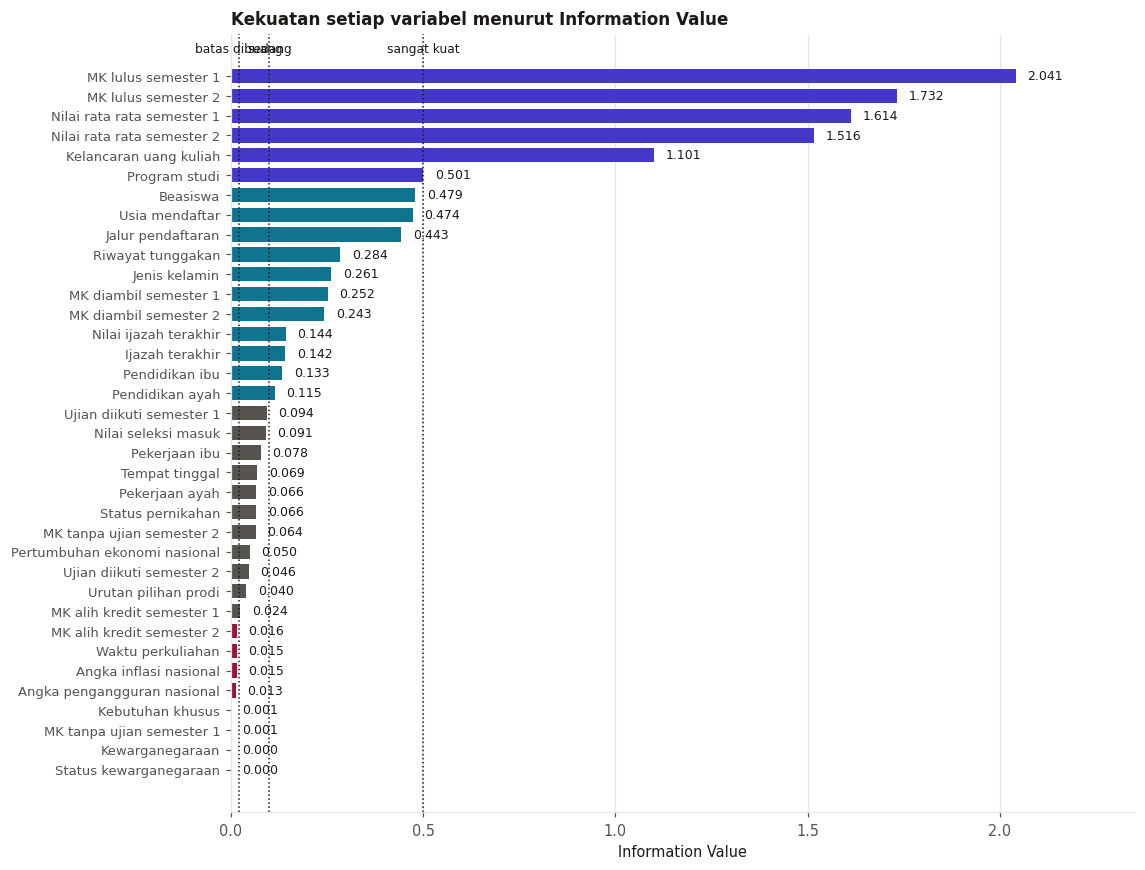

In [8]:
gambar, sumbu = plt.subplots(figsize=(10.5, 8))
urut = tabel_iv.sort_values("iv")
warna_iv = [MERAH if v < 0.02 else (BATU if v < 0.1 else (BIRU if v < 0.5 else NILA))
            for v in urut.iv]
sumbu.barh(urut.Nama, urut.iv, color=warna_iv, height=0.72)
for posisi, nilai in enumerate(urut.iv):
    sumbu.text(nilai + 0.03, posisi, f"{nilai:.3f}", va="center", fontsize=8.2)
for batas, keterangan in [(0.02, "batas dibuang"), (0.1, "sedang"), (0.5, "sangat kuat")]:
    sumbu.axvline(batas, color=TINTA, linestyle=":", linewidth=1)
    sumbu.text(batas, len(urut) + 0.2, keterangan, fontsize=8, ha="center", color=TINTA)
sumbu.set_title("Kekuatan setiap variabel menurut Information Value")
sumbu.set_xlabel("Information Value")
sumbu.set_xlim(0, 2.35)
sumbu.tick_params(axis="y", labelsize=8.6)
sumbu.yaxis.grid(False)
bersihkan(sumbu, tanpa_garis_x=False)
simpan(gambar, "01_peringkat_information_value")

**Insight 1.** Peringkat Information Value langsung menjawab permasalahan bisnis pertama
dan sekaligus menyusun bahan kartu skor.

Empat variabel teratas seluruhnya berasal dari sistem akademik: jumlah mata kuliah lulus
di dua semester pertama dan nilai rata rata keduanya, dengan IV antara 1,5 dan 2,0. Di
bawahnya, kelancaran uang kuliah mencapai 1,10, satu satunya variabel non akademik yang
masuk kelompok sangat kuat.

Nilai IV di atas 0,5 pada dunia kredit biasanya menjadi alarm kebocoran informasi, yaitu
tanda bahwa variabel tersebut sebenarnya sudah memuat jawabannya. Di sini alarm itu perlu
diperiksa, dan hasil pemeriksaannya: catatan akademik tahun pertama memang tercatat lebih
dulu daripada keputusan berhenti, sehingga bukan kebocoran. Yang benar adalah bahwa
sinyalnya memang sekuat itu. Mahasiswa yang tidak meluluskan satu pun mata kuliah di
tahun pertamanya nyaris pasti tidak melanjutkan.

Delapan variabel berada di bawah batas 0,02 dan dibuang: dua kolom alih kredit dan mata
kuliah tanpa ujian, waktu perkuliahan, kebutuhan khusus, kewarganegaraan, serta ketiga
statistik nasional. Kolom statistik nasional memang tidak mungkin membedakan mahasiswa,
karena nilainya sama untuk semua orang pada tahun yang sama.

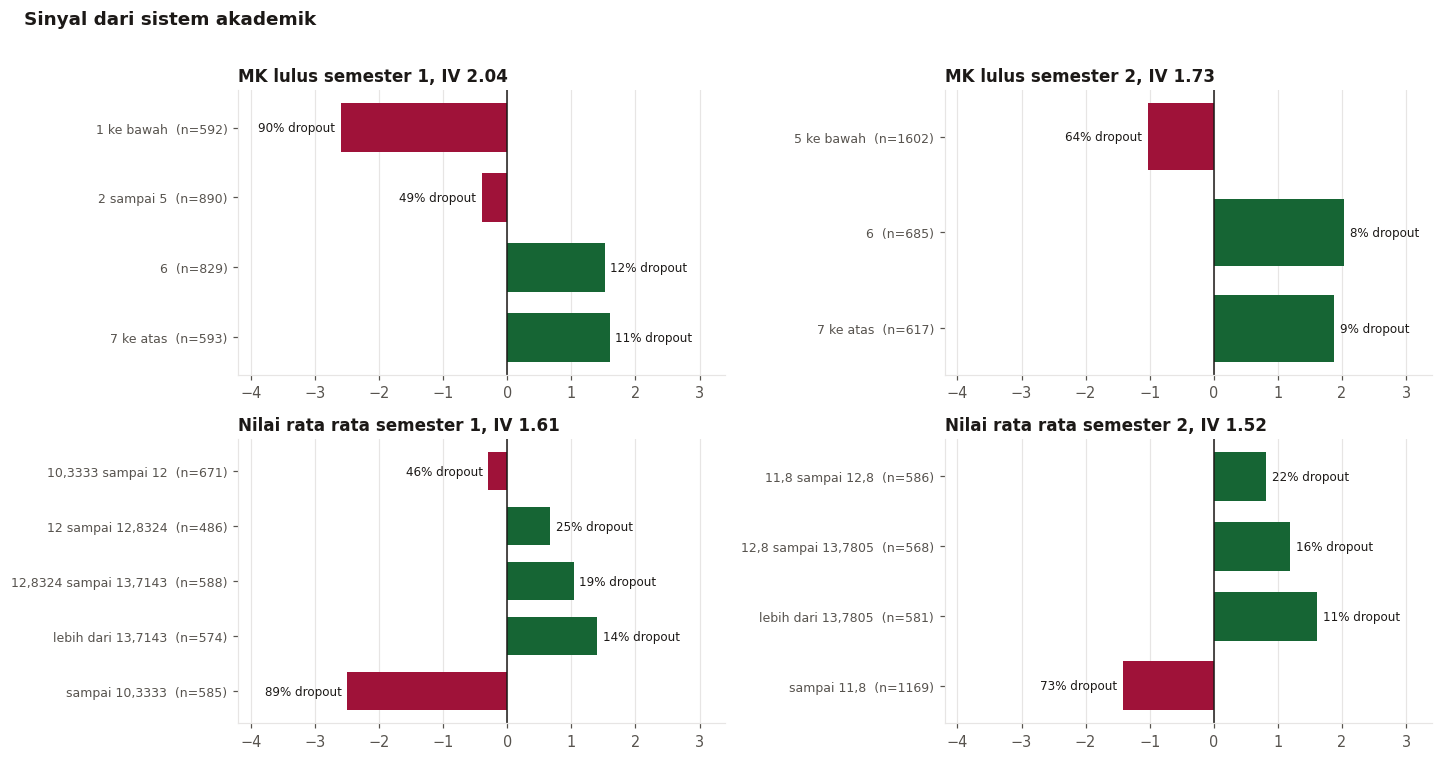

In [9]:
# --- Bentuk hubungan tiap pita dengan risiko ------------------------------
def gambar_woe(daftar_kolom, judul_besar, nama_berkas, kolom_gambar=2):
    baris_gambar = int(np.ceil(len(daftar_kolom) / kolom_gambar))
    gambar, sumbu = plt.subplots(baris_gambar, kolom_gambar,
                                 figsize=(6.6 * kolom_gambar, 3.5 * baris_gambar))
    sumbu = np.atleast_1d(sumbu).ravel()
    tabel = pembagi.tabel_pita()
    for indeks, kolom in enumerate(daftar_kolom):
        bagian = tabel[tabel.kolom == kolom].copy()
        if kolom in lb.TERJEMAHAN:
            bagian["label"] = [lb.label_pita_kategori(kolom, p) for p in bagian.pita]
            bagian = bagian.sort_values("woe")
        else:
            bagian["label"] = bagian.pita
            bagian = bagian.iloc[::-1]
        warna = [HIJAU if w > 0 else MERAH for w in bagian.woe]
        sumbu[indeks].barh(range(len(bagian)), bagian.woe, color=warna, height=0.7)
        sumbu[indeks].set_yticks(range(len(bagian)))
        sumbu[indeks].set_yticklabels(
            [f"{str(l)[:34]}  (n={int(n)})" for l, n in zip(bagian.label, bagian.jumlah)],
            fontsize=8.2)
        for posisi, (w, d) in enumerate(zip(bagian.woe, bagian.tingkat_dropout)):
            sumbu[indeks].text(w + (0.09 if w >= 0 else -0.09), posisi,
                               f"{d * 100:.0f}% dropout", va="center", fontsize=7.8,
                               ha="left" if w >= 0 else "right", color=TINTA)
        sumbu[indeks].axvline(0, color=TINTA, linewidth=1)
        sumbu[indeks].set_title(f"{lb.nama_variabel(kolom)}, IV {pembagi.iv_[kolom]:.2f}")
        sumbu[indeks].set_xlim(-4.2, 3.4)
        sumbu[indeks].yaxis.grid(False)
        bersihkan(sumbu[indeks], tanpa_garis_x=False)
    for kosong in range(len(daftar_kolom), len(sumbu)):
        sumbu[kosong].axis("off")
    gambar.suptitle(judul_besar, x=0.02, ha="left", fontsize=12, fontweight="bold")
    gambar.tight_layout(rect=[0, 0, 1, 0.97])
    gambar.savefig(f"assets/{nama_berkas}.png", dpi=150, bbox_inches="tight",
                   facecolor="white")
    plt.show()


gambar_woe(["Curricular_units_1st_sem_approved", "Curricular_units_2nd_sem_approved",
            "Curricular_units_1st_sem_grade", "Curricular_units_2nd_sem_grade"],
           "Sinyal dari sistem akademik", "02_woe_akademik")

**Insight 2.** Keempat variabel akademik memisahkan populasi dengan sangat tajam, dan
seluruh pitanya bergerak satu arah setelah penggabungan monoton.

Mahasiswa yang meluluskan paling banyak satu mata kuliah pada semester pertama berakhir
berhenti pada sekitar sembilan dari sepuluh kasus. Begitu jumlah kelulusan mencapai enam
mata kuliah, angkanya jatuh ke kisaran satu dari delapan. Pola serupa berulang pada
semester kedua dan pada kedua kolom nilai rata rata.

Yang menarik, batas pemisah terkuat bukan berada di angka nol, melainkan di sekitar lima
sampai enam mata kuliah lulus per semester. Artinya mahasiswa yang lulus separuh beban
studinya sudah berada dalam bahaya, bukan hanya mahasiswa yang gagal sepenuhnya. Ini
penting bagi institusi, karena kelompok separuh jalan itu justru yang paling mungkin
diselamatkan.

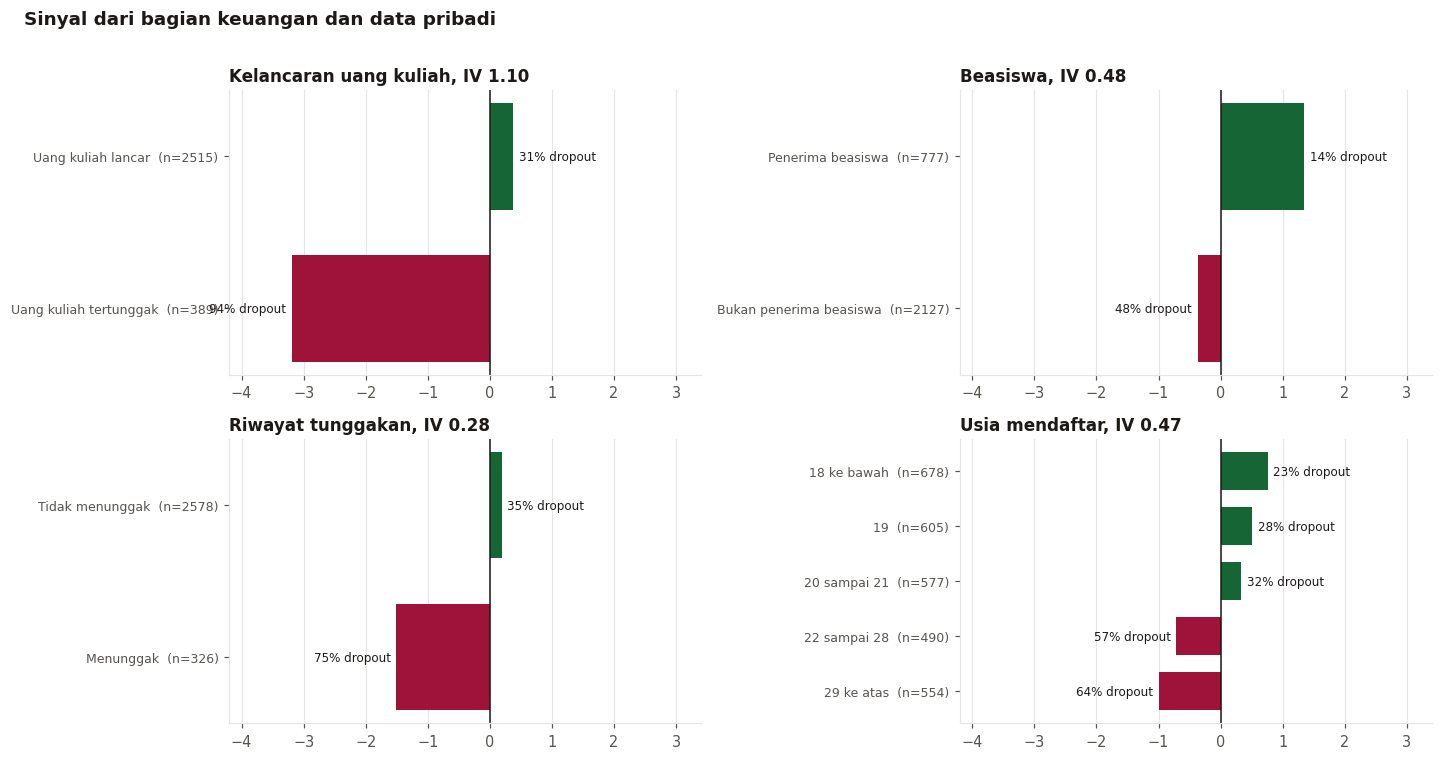

In [10]:
gambar_woe(["Tuition_fees_up_to_date", "Scholarship_holder", "Debtor",
            "Age_at_enrollment"],
           "Sinyal dari bagian keuangan dan data pribadi", "03_woe_keuangan")

**Insight 3.** Kelancaran uang kuliah adalah variabel non akademik terkuat dengan IV 1,10.
Mahasiswa yang pembayarannya tertunggak berakhir berhenti pada 94,1 persen kasus,
sedangkan yang lancar 30,7 persen. Selisih 63 poin persen dari satu kolom yang sudah
dimiliki bagian keuangan sejak hari pertama.

Perbedaan sebesar itu menggoda untuk dibaca sebagai sebab akibat, seolah melunasi
tunggakan akan menyelamatkan mahasiswa. Pembacaan yang lebih hati hati: berhenti membayar
bisa menjadi penyebab berhentinya kuliah, tetapi bisa juga menjadi gejala dari keputusan
berhenti yang sudah diambil diam diam beberapa bulan sebelumnya. Untuk keperluan
peringatan dini keduanya sama sama berguna, tetapi untuk keperluan menyusun kebijakan
keringanan biaya, perbedaan itu menentukan.

Beasiswa bergerak ke arah sebaliknya, dari 48,2 persen pada bukan penerima menjadi 14,3
persen pada penerima, dan riwayat tunggakan menegaskan pola yang sama. Usia mendaftar
naik bertahap dari 23,2 persen pada kelompok 18 tahun ke bawah sampai 31,5 persen pada
kelompok 20 sampai 21 tahun, lalu melonjak ke 56,7 persen begitu memasuki kelompok 22
sampai 28 tahun. Lonjakan itu menandai titik ketika kuliah mulai bersaing dengan pekerjaan
dan tanggung jawab keluarga.

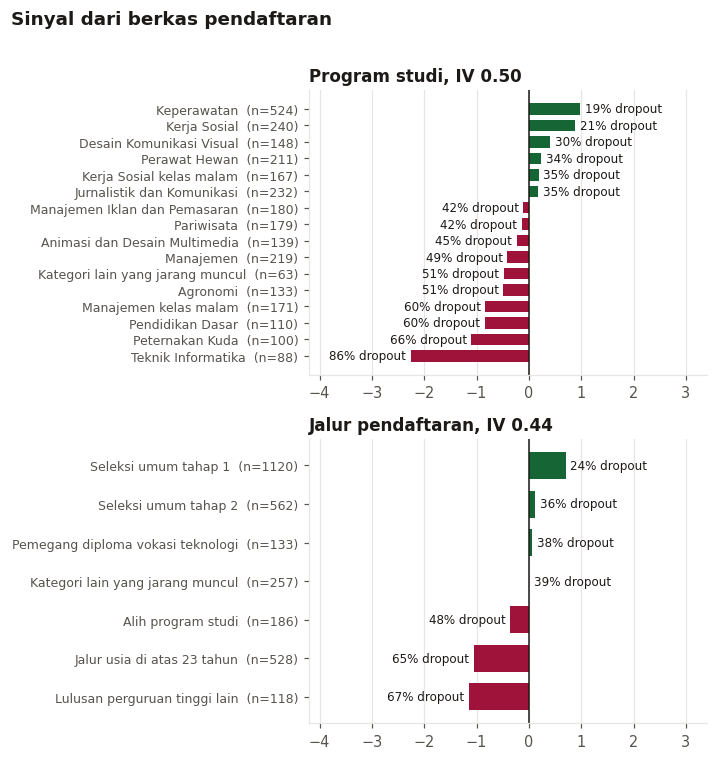

In [11]:
gambar_woe(["Course", "Application_mode"],
           "Sinyal dari berkas pendaftaran", "04_woe_pendaftaran", kolom_gambar=1)

**Insight 4.** Program studi dan jalur pendaftaran sama sama masuk kategori kuat, dan
keduanya menunjukkan bahwa risiko sudah melekat sebelum perkuliahan dimulai.

Keperawatan pada 19,5 persen dan Kerja Sosial pada 20,8 persen berada di ujung teraman,
sementara Teknik Informatika pada 86,4 persen dan Peternakan Kuda pada 66,0 persen berada
di ujung sebaliknya, lebih dari tiga kali lipat. Selisih
sebesar ini tidak dapat dijelaskan oleh mutu mahasiswa semata, dan lebih tepat dibaca
sebagai persoalan program: beban mata kuliah tahun pertama, ketersediaan asistensi, atau
kecocokan antara gambaran calon mahasiswa dan kenyataan kuliahnya.

Pada jalur pendaftaran, jalur usia di atas 23 tahun pada 65,0 persen dan jalur lulusan
perguruan tinggi lain pada 66,9 persen berisiko jauh lebih tinggi daripada seleksi umum
tahap pertama pada 24,2 persen. Keduanya
menampung mahasiswa yang datang dengan tanggung jawab hidup yang sudah lebih berat.

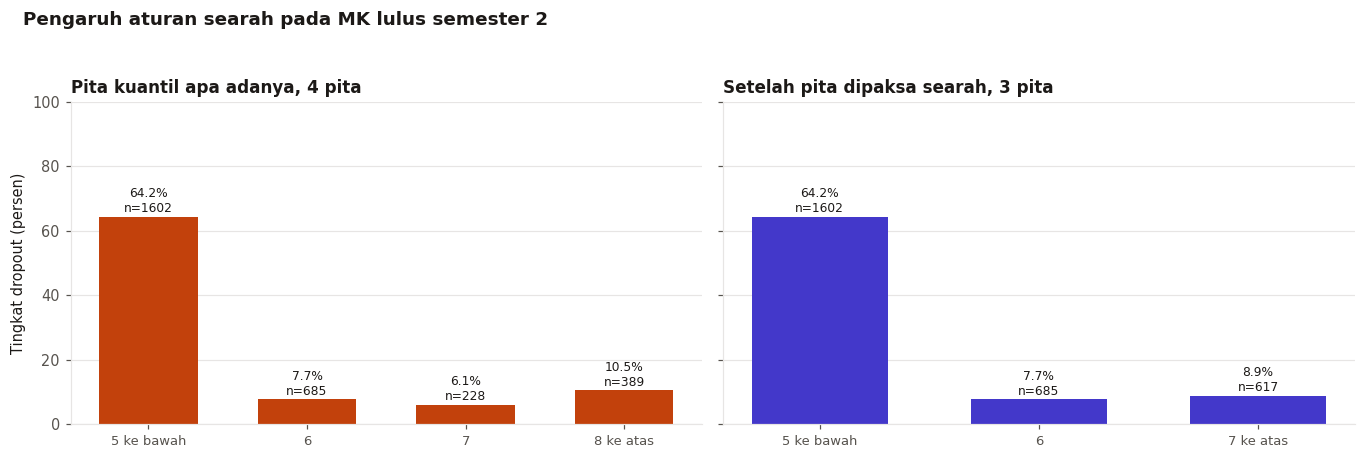

Jumlah pita sebelum diseragamkan arahnya : 208
Jumlah pita sesudah diseragamkan arahnya : 159


In [12]:
# --- Bukti kerja penggabungan pita monoton -------------------------------
# Dibuat dua pembagi pembanding: satu tanpa aturan searah, satu dengan aturan searah.
pembagi_bebas = ksk.PitaWOE(jumlah_pita=5, monoton=False).fit(X_latih, y_latih)
contoh_kolom = "Curricular_units_2nd_sem_approved"

gambar, sumbu = plt.subplots(1, 2, figsize=(12.5, 4.2), sharey=True)
for indeks, (pem, judul) in enumerate([(pembagi_bebas, "Pita kuantil apa adanya"),
                                       (pembagi, "Setelah pita dipaksa searah")]):
    tabel = pem.tabel_pita()
    bagian = tabel[tabel.kolom == contoh_kolom]
    batang = sumbu[indeks].bar(range(len(bagian)), bagian.tingkat_dropout * 100,
                               color=[NILA if indeks else BATA] * len(bagian), width=0.62)
    sumbu[indeks].set_xticks(range(len(bagian)))
    sumbu[indeks].set_xticklabels(bagian.pita, fontsize=8.6)
    for b, (nilai, jumlah) in zip(batang, zip(bagian.tingkat_dropout, bagian.jumlah)):
        sumbu[indeks].text(b.get_x() + b.get_width() / 2, nilai * 100 + 1.5,
                           f"{nilai * 100:.1f}%\nn={int(jumlah)}", ha="center", fontsize=8)
    sumbu[indeks].set_title(f"{judul}, {len(bagian)} pita")
    sumbu[indeks].set_ylim(0, 100)
    bersihkan(sumbu[indeks])
sumbu[0].set_ylabel("Tingkat dropout (persen)")
gambar.suptitle(f"Pengaruh aturan searah pada {lb.nama_variabel(contoh_kolom)}",
                x=0.02, ha="left", fontsize=12, fontweight="bold")
gambar.tight_layout(rect=[0, 0, 1, 0.94])
gambar.savefig("assets/05_pita_searah.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Jumlah pita sebelum diseragamkan arahnya : "
      f"{sum(len(v) for v in pembagi_bebas.woe_.values())}")
print(f"Jumlah pita sesudah diseragamkan arahnya : "
      f"{sum(len(v) for v in pembagi.woe_.values())}")

**Insight 5.** Grafik ini memperlihatkan langsung apa yang dikerjakan aturan searah.

Pembagian kuantil apa adanya menghasilkan pita yang berbalik arah: kelompok dengan tujuh
mata kuliah lulus tercatat sedikit lebih berisiko daripada kelompok delapan ke atas,
padahal secara akal sehat seharusnya sebaliknya. Selisih itu hanya riak sampel, tetapi
kalau dibiarkan masuk ke kartu skor, ia akan muncul sebagai baris yang mustahil
dijelaskan kepada mahasiswa.

Setelah pita bertetangga yang berbalik arah digabung, seluruh variabel angka bergerak
satu arah. Harga yang dibayar adalah berkurangnya jumlah pita, dan bagian 7 menunjukkan
bahwa harga itu sangat kecil dibanding kejelasan yang didapat.

## 5. Data Preparation: Menyaring Variabel Calon Kartu

Kartu skor yang baik tidak memuat seluruh variabel yang tersedia. Ia memuat variabel
paling sedikit yang masih memberi hasil hampir sama, karena kartu yang panjang tidak akan
pernah dipakai. Penyaringan dilakukan dalam tiga saringan berturut turut.

**Saringan pertama, kekuatan.** Variabel dengan Information Value di bawah 0,02 dibuang.
Ia tidak membedakan apa apa, dan mempertahankannya hanya menambah baris kartu.

**Saringan kedua, kepatutan.** Ada variabel yang secara angka berguna tetapi tidak patut
dipakai untuk memberi perlakuan berbeda kepada mahasiswa. Jenis kelamin masuk kategori
ini. Information Value-nya 0,26, cukup untuk lolos saringan pertama, tetapi memakainya
berarti institusi memberi poin risiko kepada seseorang karena hal yang tidak dapat ia
ubah dan tidak dapat ia perbaiki lewat bimbingan apa pun. Selisih tingkat dropout antara
mahasiswa laki laki dan perempuan tetap penting untuk diketahui dan tetap dilaporkan pada
bagian EDA, tetapi tempatnya adalah pada perancangan program bimbingan, bukan di dalam
kartu skor perorangan.

**Saringan ketiga, keringkasan.** Dari variabel yang tersisa diambil dua belas teratas
menurut Information Value. Bagian 6 memeriksa apakah pemangkasan ini benar benar merugi.

In [13]:
# Variabel yang sengaja tidak dipakai pada kartu skor meskipun cukup kuat secara angka.
DILARANG = ["Gender"]

lolos_iv = [k for k in tabel_iv[tabel_iv.iv >= 0.02].kolom]
dibuang_iv = [k for k in tabel_iv[tabel_iv.iv < 0.02].kolom]
kandidat = [k for k in lolos_iv if k not in DILARANG][:12]

print(f"Variabel awal                       : {len(tabel_iv)}")
print(f"Dibuang karena IV di bawah 0,02     : {len(dibuang_iv)}")
print("   " + ", ".join(lb.nama_variabel(k) for k in dibuang_iv))
print(f"Dibuang karena alasan kepatutan     : {len(DILARANG)}")
print("   " + ", ".join(lb.nama_variabel(k) for k in DILARANG))
print(f"Diambil sebagai calon kartu skor    : {len(kandidat)}")
for nomor, kolom in enumerate(kandidat, 1):
    print(f"   {nomor:2d}. {lb.nama_variabel(kolom):32s} IV {pembagi.iv_[kolom]:.3f}")

Variabel awal                       : 36
Dibuang karena IV di bawah 0,02     : 8
   MK alih kredit semester 2, Waktu perkuliahan, Angka inflasi nasional, Angka pengangguran nasional, Kebutuhan khusus, MK tanpa ujian semester 1, Status kewarganegaraan, Kewarganegaraan
Dibuang karena alasan kepatutan     : 1
   Jenis kelamin
Diambil sebagai calon kartu skor    : 12
    1. MK lulus semester 1              IV 2.041
    2. MK lulus semester 2              IV 1.732
    3. Nilai rata rata semester 1       IV 1.614
    4. Nilai rata rata semester 2       IV 1.516
    5. Kelancaran uang kuliah           IV 1.101
    6. Program studi                    IV 0.501
    7. Beasiswa                         IV 0.479
    8. Usia mendaftar                   IV 0.474
    9. Jalur pendaftaran                IV 0.443
   10. Riwayat tunggakan                IV 0.284
   11. MK diambil semester 1            IV 0.252
   12. MK diambil semester 2            IV 0.243


In [14]:
# Matriks WOE. Setiap kolom asli berganti menjadi satu kolom berisi nilai WOE pita
# yang ditempati mahasiswa bersangkutan, sehingga regresi logistik bekerja pada
# skala yang sama untuk semua variabel tanpa perlu penskalaan tambahan.
kolom_woe = [f"woe_{k}" for k in kandidat]
W_latih = pembagi.transform(X_latih)[kolom_woe]
W_uji = pembagi.transform(X_uji)[kolom_woe]

print(f"Matriks WOE data latih : {W_latih.shape}")
print(f"Matriks WOE data uji   : {W_uji.shape}")
print()
print("Cuplikan lima baris pertama, tiga kolom pertama")
print(W_latih.iloc[:5, :3].round(3).to_string())

Matriks WOE data latih : (2904, 12)
Matriks WOE data uji   : (726, 12)

Cuplikan lima baris pertama, tiga kolom pertama
      woe_Curricular_units_1st_sem_approved  woe_Curricular_units_2nd_sem_approved  woe_Curricular_units_1st_sem_grade
3732                                 -2.597                                 -1.026                              -2.496
1803                                  1.519                                 -1.026                              -0.295
1554                                  1.519                                  2.029                               1.404
2268                                 -0.400                                 -1.026                               0.672
1205                                 -0.400                                 -1.026                              -0.295


## 6. Modeling: dari Regresi Logistik menjadi Kartu Skor

### 6.1. Memeriksa arah setiap koefisien

Regresi logistik dilatih di atas matriks WOE. Karena WOE tinggi berarti pita yang lebih
aman, seluruh koefisien seharusnya bertanda negatif. Koefisien bertanda positif berarti
model menyimpulkan hal yang berlawanan dengan data mentahnya sendiri, dan itu hampir
selalu gejala tumpang tindih informasi antar variabel.

Pada kasus ini gejalanya dapat ditebak: jumlah mata kuliah yang diambil dan jumlah yang
lulus bergerak beriringan. Ketika keduanya masuk model bersama sama, satu di antaranya
dapat berbalik tanda karena tugasnya sudah diambil alih yang lain.

Variabel bertanda salah dibuang satu per satu, mulai dari yang koefisiennya paling
positif, lalu model dilatih ulang. Proses berhenti ketika seluruh koefisien sudah searah.

In [15]:
variabel_kartu = list(kandidat)
dibuang_tanda = []

while True:
    W = pembagi.transform(X_latih)[[f"woe_{k}" for k in variabel_kartu]]
    model_kartu = LogisticRegression(max_iter=3000, random_state=ACAK).fit(W, y_latih)
    koefisien = pd.Series(model_kartu.coef_[0], index=variabel_kartu)
    salah_arah = koefisien[koefisien > 0]
    if salah_arah.empty:
        break
    tersangka = salah_arah.idxmax()
    dibuang_tanda.append((tersangka, float(salah_arah.max())))
    variabel_kartu.remove(tersangka)

print(f"Variabel dibuang karena arah koefisien berlawanan: {len(dibuang_tanda)}")
for nama, nilai in dibuang_tanda:
    print(f"   {lb.nama_variabel(nama):32s} koefisien {nilai:+.3f}")
print(f"\nVariabel akhir kartu skor: {len(variabel_kartu)}")
ringkas_koef = pd.DataFrame({
    "Variabel": [lb.nama_variabel(k) for k in variabel_kartu],
    "IV": [round(pembagi.iv_[k], 3) for k in variabel_kartu],
    "Koefisien": model_kartu.coef_[0].round(3),
}).sort_values("Koefisien")
print(ringkas_koef.to_string(index=False))

Variabel dibuang karena arah koefisien berlawanan: 2


   MK diambil semester 2            koefisien +1.997
   MK diambil semester 1            koefisien +1.958

Variabel akhir kartu skor: 10
                  Variabel    IV  Koefisien
    Kelancaran uang kuliah 1.101     -0.749
                  Beasiswa 0.479     -0.587
         Riwayat tunggakan 0.284     -0.535
Nilai rata rata semester 2 1.516     -0.424
         Jalur pendaftaran 0.443     -0.423
       MK lulus semester 2 1.732     -0.421
             Program studi 0.501     -0.302
            Usia mendaftar 0.474     -0.290
       MK lulus semester 1 2.041     -0.285
Nilai rata rata semester 1 1.614     -0.243


### 6.2. Menerjemahkan koefisien menjadi poin

Rumus baku kartu skor dipakai apa adanya:

```
faktor = pdo / ln(2)
offset = skor_dasar - faktor * ln(odds_dasar)
poin   = -(koefisien * WOE + intersep / n) * faktor + offset / n
```

Tiga angka pengatur ditetapkan sebagai berikut.

* **Skor dasar 600** pada **odds satu banding satu**. Artinya mahasiswa yang berskor 600
  memiliki peluang selamat dan peluang berhenti yang sama besar.
* **PDO 20**, singkatan dari points to double the odds. Setiap tambahan 20 poin
  melipatduakan perbandingan peluang selamat terhadap peluang berhenti.

Ketiganya hanya mengatur penampilan angka, bukan urutan mahasiswa. Skor 600 dan PDO 20
dipilih karena keduanya lazim dipakai sehingga rentang skor yang muncul terasa wajar bagi
siapa pun yang pernah melihat kartu skor kredit.

In [16]:
KARTU = ksk.susun_kartu(pembagi, model_kartu, variabel_kartu,
                        pdo=20.0, skor_dasar=600.0, odds_dasar=1.0)
KARTU["variabel"] = KARTU.kolom.map(lb.nama_variabel)
KARTU["label"] = [lb.label_pita_kategori(baris.kolom, baris.pita)
                  if baris.kolom in lb.TERJEMAHAN else baris.pita
                  for baris in KARTU.itertuples()]

print(f"Kartu skor berisi {len(KARTU)} baris untuk {KARTU.kolom.nunique()} variabel.\n")
for kolom in variabel_kartu:
    bagian = KARTU[KARTU.kolom == kolom].sort_values("poin", ascending=False)
    print(f"{lb.nama_variabel(kolom)}  (poin dasar {int(bagian.poin_dasar.iloc[0])})")
    for baris in bagian.itertuples():
        print(f"    {str(baris.label)[:44]:46s} {baris.poin:4d} poin  ({baris.selisih_poin:+d})")
    print()

Kartu skor berisi 50 baris untuk 10 variabel.

MK lulus semester 1  (poin dasar 62)
    7 ke atas                                        74 poin  (+12)
    6                                                74 poin  (+12)
    2 sampai 5                                       58 poin  (-4)
    1 ke bawah                                       40 poin  (-22)

MK lulus semester 2  (poin dasar 73)
    6                                                86 poin  (+13)
    7 ke atas                                        84 poin  (+11)
    5 ke bawah                                       49 poin  (-24)

Nilai rata rata semester 1  (poin dasar 62)
    lebih dari 13,7143                               71 poin  (+9)
    12,8324 sampai 13,7143                           69 poin  (+7)
    12 sampai 12,8324                                66 poin  (+4)
    10,3333 sampai 12                                59 poin  (-3)
    sampai 10,3333                                   44 poin  (-18)

Nilai rata rata semes

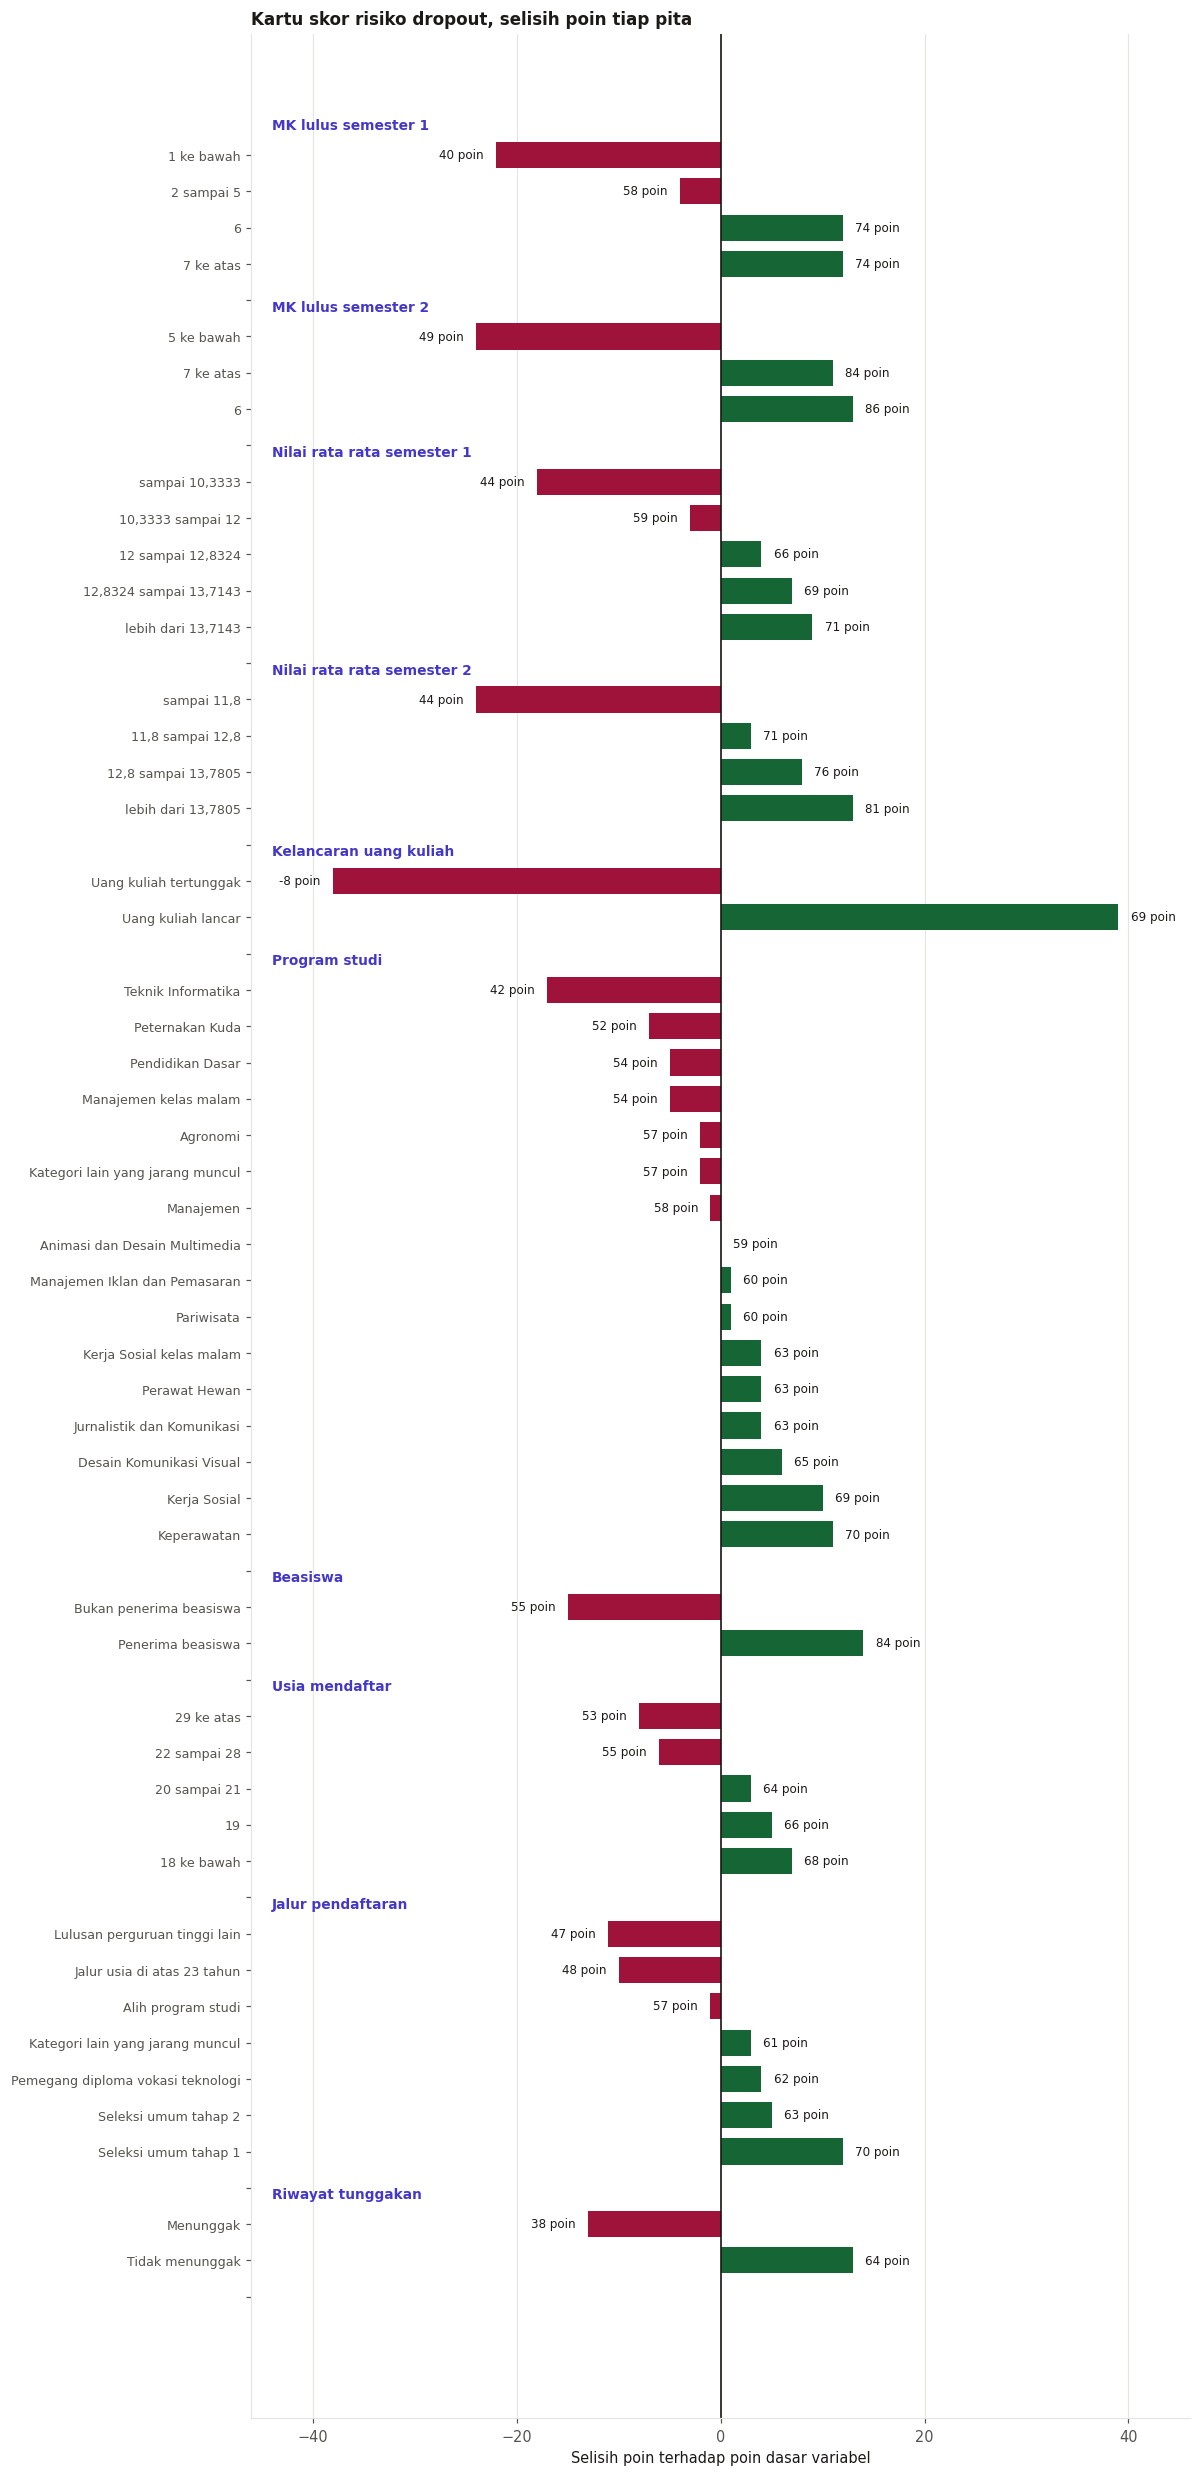

In [17]:
# --- Kartu skor dalam bentuk gambar --------------------------------------
urutan_variabel = list(dict.fromkeys(KARTU.kolom))
tinggi = 0.42 * len(KARTU) + 1.6
gambar, sumbu = plt.subplots(figsize=(11, tinggi))

posisi = 0
label_sumbu, warna_batang, nilai_batang, penanda = [], [], [], []
for kolom in urutan_variabel:
    bagian = KARTU[KARTU.kolom == kolom].sort_values("selisih_poin")
    for baris in bagian.itertuples():
        label_sumbu.append(f"{str(baris.label)[:40]}")
        nilai_batang.append(baris.selisih_poin)
        warna_batang.append(HIJAU if baris.selisih_poin >= 0 else MERAH)
        penanda.append(baris.poin)
    label_sumbu.append("")
    nilai_batang.append(0)
    warna_batang.append("white")
    penanda.append(None)

sumbu.barh(range(len(nilai_batang)), nilai_batang, color=warna_batang, height=0.72)
sumbu.set_yticks(range(len(label_sumbu)))
sumbu.set_yticklabels(label_sumbu, fontsize=8.3)
sumbu.invert_yaxis()
for indeks, (nilai, poin) in enumerate(zip(nilai_batang, penanda)):
    if poin is None:
        continue
    sumbu.text(nilai + (1.2 if nilai >= 0 else -1.2), indeks, f"{poin} poin",
               va="center", ha="left" if nilai >= 0 else "right", fontsize=7.8)
batas_atas = 0
for kolom in urutan_variabel:
    jumlah = len(KARTU[KARTU.kolom == kolom])
    sumbu.text(-44, batas_atas - 0.7, lb.nama_variabel(kolom), fontsize=9,
               fontweight="bold", color=NILA)
    batas_atas += jumlah + 1
sumbu.axvline(0, color=TINTA, linewidth=1.1)
sumbu.set_xlim(-46, 46)
sumbu.set_xlabel("Selisih poin terhadap poin dasar variabel")
sumbu.set_title("Kartu skor risiko dropout, selisih poin tiap pita")
sumbu.yaxis.grid(False)
bersihkan(sumbu, tanpa_garis_x=False)
simpan(gambar, "06_kartu_skor")

**Insight 6.** Kartu skor yang sudah jadi dapat dibaca seperti daftar harga.

Pita paling menghukum adalah uang kuliah yang tertunggak dengan minus 38 poin, disusul
kelulusan lima mata kuliah ke bawah pada semester dua dan nilai rata rata semester dua di
bawah 11,8, keduanya minus 24 poin. Sebaliknya, pita paling menolong adalah uang kuliah
yang lancar dengan tambahan 39 poin, status penerima beasiswa dengan 14 poin, dan
kelulusan enam mata kuliah pada semester dua dengan 13 poin.

Yang perlu diperhatikan staf: sebagian besar variabel hanya menggeser skor beberapa poin,
sementara segelintir variabel menggeser puluhan poin. Kartu ini karena itu tidak boleh
dibaca sebagai daftar periksa yang seluruh barisnya sama penting. Dua atau tiga baris
teratas menentukan sebagian besar nasib skornya, dan justru itulah yang membuat kartu
mudah dijelaskan dalam percakapan singkat.

In [18]:
# --- Menghitung skor dan memeriksa keselarasannya dengan model -----------
skor_latih = ksk.hitung_skor(KARTU, pembagi, X_latih)
skor_uji = ksk.hitung_skor(KARTU, pembagi, X_uji)
peluang_uji = model_kartu.predict_proba(
    pembagi.transform(X_uji)[[f"woe_{k}" for k in variabel_kartu]])[:, 1]

print(f"Rentang skor data latih : {skor_latih.min():.0f} sampai {skor_latih.max():.0f}")
print(f"Rentang skor data uji   : {skor_uji.min():.0f} sampai {skor_uji.max():.0f}")
print(f"Rata rata skor          : {skor_uji.mean():.0f}")
print()
print(f"Korelasi skor dengan peluang model : {np.corrcoef(skor_uji, peluang_uji)[0, 1]:.4f}")
print(f"ROC-AUC memakai peluang model      : {roc_auc_score(y_uji, peluang_uji):.4f}")
print(f"ROC-AUC memakai skor kartu         : {roc_auc_score(y_uji, -skor_uji):.4f}")
print()
print("Kedua angka ROC-AUC praktis sama. Pembulatan poin ke bilangan bulat tidak")
print("merusak urutan mahasiswa, sehingga kartu boleh dipakai menggantikan model.")

Rentang skor data latih : 405 sampai 737
Rentang skor data uji   : 415 sampai 736
Rata rata skor          : 620

Korelasi skor dengan peluang model : -0.9674
ROC-AUC memakai peluang model      : 0.9201
ROC-AUC memakai skor kartu         : 0.9202

Kedua angka ROC-AUC praktis sama. Pembulatan poin ke bilangan bulat tidak
merusak urutan mahasiswa, sehingga kartu boleh dipakai menggantikan model.


## 7. Evaluation

### 7.1. Sebaran skor dan ambang keputusan

Ambang keputusan dipilih memakai **statistik Kolmogorov Smirnov**, ukuran baku pada dunia
kartu skor. KS adalah jarak vertikal terbesar antara dua kurva sebaran kumulatif, yaitu
sebaran skor mahasiswa yang selamat dan sebaran skor mahasiswa yang berhenti. Titik
tempat jarak itu terbesar adalah skor yang paling tegas memisahkan keduanya.

Nilai KS dihitung pada data latih, bukan pada data uji, supaya data uji tetap murni.

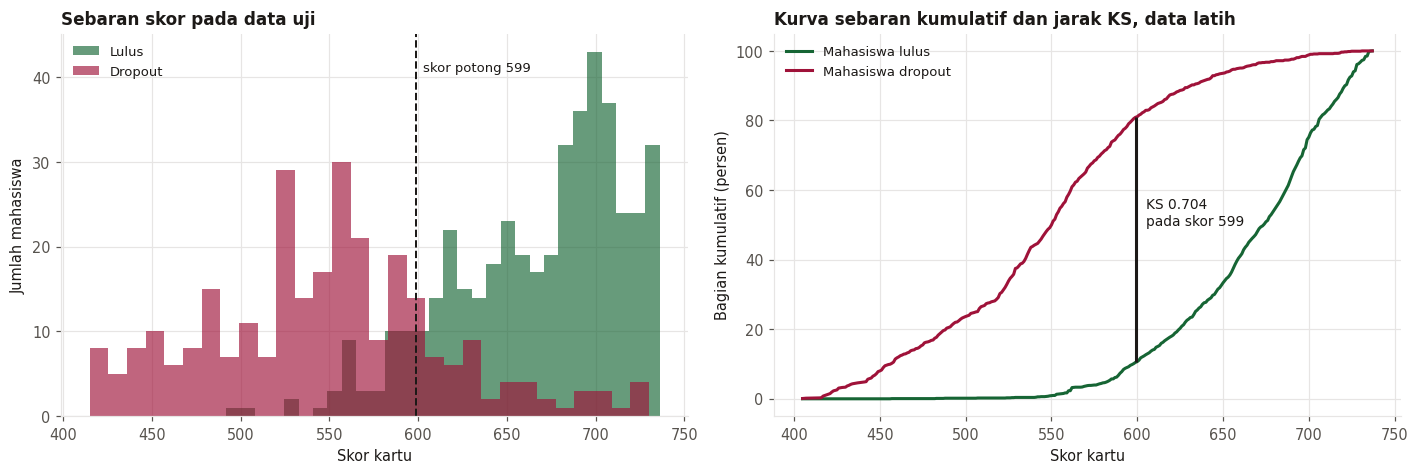

Statistik KS pada data latih: 0.7044 pada skor 599


In [19]:
fpr, tpr, ambang_kurva = roc_curve(y_latih, -skor_latih)
nilai_ks = float((tpr - fpr).max())
skor_potong = float(-ambang_kurva[(tpr - fpr).argmax()])

gambar, sumbu = plt.subplots(1, 2, figsize=(13, 4.4))

for label, warna, saring in [("Lulus", HIJAU, y_uji == 0), ("Dropout", MERAH, y_uji == 1)]:
    sumbu[0].hist(skor_uji[saring.to_numpy()], bins=30, alpha=0.65, color=warna, label=label)
sumbu[0].axvline(skor_potong, color=TINTA, linestyle="--", linewidth=1.3)
sumbu[0].text(skor_potong + 4, sumbu[0].get_ylim()[1] * 0.9,
              f"skor potong {skor_potong:.0f}", fontsize=8.6)
sumbu[0].set_title("Sebaran skor pada data uji")
sumbu[0].set_xlabel("Skor kartu")
sumbu[0].set_ylabel("Jumlah mahasiswa")
sumbu[0].legend(fontsize=8.6)
bersihkan(sumbu[0], tanpa_garis_x=False)

urut_skor = np.sort(np.unique(skor_latih))
kumulatif_aman = [(skor_latih[y_latih.to_numpy() == 0] <= s).mean() for s in urut_skor]
kumulatif_risiko = [(skor_latih[y_latih.to_numpy() == 1] <= s).mean() for s in urut_skor]
sumbu[1].plot(urut_skor, np.array(kumulatif_aman) * 100, color=HIJAU, linewidth=2,
              label="Mahasiswa lulus")
sumbu[1].plot(urut_skor, np.array(kumulatif_risiko) * 100, color=MERAH, linewidth=2,
              label="Mahasiswa dropout")
jarak = np.array(kumulatif_risiko) - np.array(kumulatif_aman)
titik = int(jarak.argmax())
sumbu[1].vlines(urut_skor[titik], kumulatif_aman[titik] * 100, kumulatif_risiko[titik] * 100,
                color=TINTA, linewidth=2)
sumbu[1].text(urut_skor[titik] + 6, 50, f"KS {nilai_ks:.3f}\npada skor {urut_skor[titik]:.0f}",
              fontsize=9)
sumbu[1].set_title("Kurva sebaran kumulatif dan jarak KS, data latih")
sumbu[1].set_xlabel("Skor kartu")
sumbu[1].set_ylabel("Bagian kumulatif (persen)")
sumbu[1].legend(fontsize=8.6, loc="upper left")
bersihkan(sumbu[1], tanpa_garis_x=False)

simpan(gambar, "07_sebaran_skor_dan_ks")
print(f"Statistik KS pada data latih: {nilai_ks:.4f} pada skor {skor_potong:.0f}")

**Insight 7.** Sebaran skor kedua kelompok nyaris tidak bertumpang tindih di kedua
ujungnya. Mahasiswa yang berhenti menumpuk di bawah skor 550 dan mahasiswa yang lulus
menumpuk di atas 650, dengan wilayah abu abu yang sempit di antaranya.

Statistik KS mencapai 0,70 pada skor potong sekitar 600. Pada praktik kartu skor kredit,
KS di atas 0,40 sudah dianggap kartu yang kuat, sehingga angka 0,70 tergolong sangat baik.
Perlu diingat bahwa perbandingannya tidak sepenuhnya setara, karena kartu skor kredit
memprediksi kejadian yang jauh lebih jarang.

Kebetulan yang menyenangkan, skor potong hasil perhitungan KS jatuh hampir persis di skor
dasar 600, angka yang memang dirancang sebagai titik peluang seimbang. Ini memudahkan
penjelasan kepada staf: mahasiswa berskor di bawah 600 lebih mungkin berhenti daripada
bertahan.

### 7.2. Peringkat huruf A sampai E

Skor mentah berguna untuk mengurutkan, tetapi tidak nyaman untuk mengelola pekerjaan
sehari hari. Karena itu skor dibagi menjadi lima peringkat huruf, dengan dua pertimbangan:

* batas antara **C dan D** ditetapkan tepat pada skor potong KS, sehingga seluruh
  mahasiswa berperingkat D dan E adalah mereka yang dipanggil sistem untuk dibimbing,
* batas lainnya diambil dari kuantil skor data latih, supaya besar tiap peringkat masuk
  akal untuk dijadwalkan.

Batas peringkat A sampai D: [695, 657, 599, 550]

Tabel peringkat pada data uji
           jumlah  skor_terendah  skor_tertinggi  tingkat_dropout  bagian
peringkat                                                                
A             172          695.0           736.0              5.2    23.7
B             123          657.0           694.0              7.3    16.9
C             157          599.0           656.0             22.9    21.6
D             127          550.0           598.0             69.3    17.5
E             147          415.0           549.0             96.6    20.2


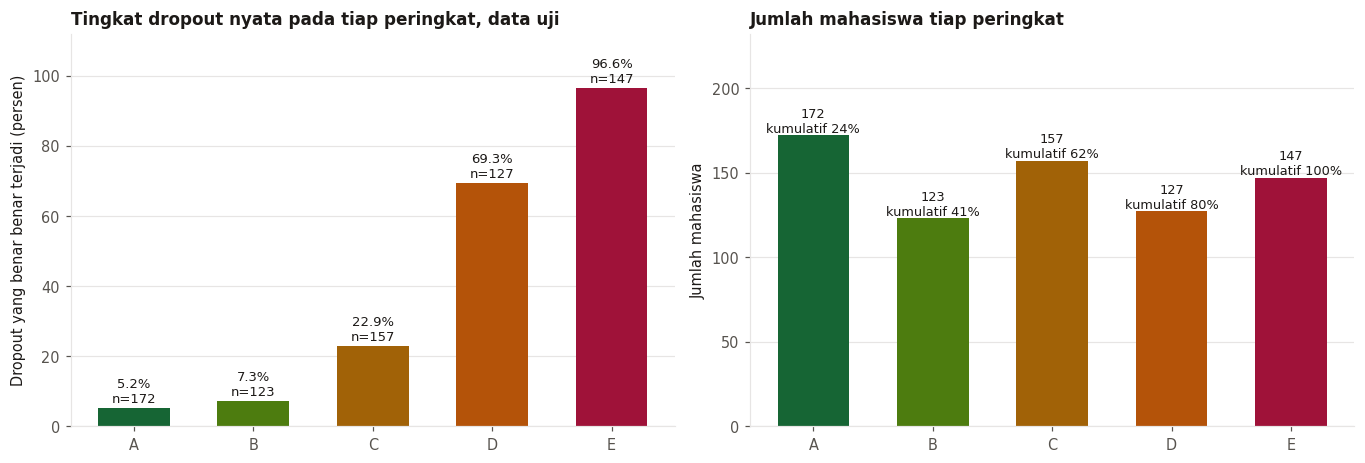

In [20]:
BATAS_PERINGKAT = [
    round(float(np.quantile(skor_latih, 0.80))),
    round(float(np.quantile(skor_latih, 0.60))),
    round(skor_potong),
    round(float(np.quantile(skor_latih, 0.20))),
]
print("Batas peringkat A sampai D:", BATAS_PERINGKAT)

peringkat_uji = ksk.beri_peringkat(skor_uji, BATAS_PERINGKAT)
tabel_peringkat = (pd.DataFrame({"peringkat": peringkat_uji.to_numpy(),
                                 "dropout": y_uji.to_numpy(),
                                 "skor": skor_uji})
                   .groupby("peringkat")
                   .agg(jumlah=("dropout", "size"), skor_terendah=("skor", "min"),
                        skor_tertinggi=("skor", "max"), tingkat_dropout=("dropout", "mean")))
tabel_peringkat["bagian"] = tabel_peringkat.jumlah / len(y_uji)
print()
print("Tabel peringkat pada data uji")
print(tabel_peringkat.assign(
    tingkat_dropout=lambda t: (t.tingkat_dropout * 100).round(1),
    bagian=lambda t: (t.bagian * 100).round(1)).to_string())

gambar, sumbu = plt.subplots(1, 2, figsize=(12.5, 4.3))
batang = sumbu[0].bar(tabel_peringkat.index, tabel_peringkat.tingkat_dropout * 100,
                      color=[WARNA_PERINGKAT[p] for p in tabel_peringkat.index], width=0.6)
for b, (nilai, jumlah) in zip(batang, zip(tabel_peringkat.tingkat_dropout,
                                          tabel_peringkat.jumlah)):
    sumbu[0].text(b.get_x() + b.get_width() / 2, nilai * 100 + 1.6,
                  f"{nilai * 100:.1f}%\nn={int(jumlah)}", ha="center", fontsize=8.6)
sumbu[0].set_title("Tingkat dropout nyata pada tiap peringkat, data uji")
sumbu[0].set_ylabel("Dropout yang benar benar terjadi (persen)")
sumbu[0].set_ylim(0, 112)
bersihkan(sumbu[0])

lebar_kumulatif = tabel_peringkat.jumlah.cumsum() / tabel_peringkat.jumlah.sum() * 100
sumbu[1].bar(tabel_peringkat.index, tabel_peringkat.jumlah,
             color=[WARNA_PERINGKAT[p] for p in tabel_peringkat.index], width=0.6)
for huruf, jumlah, kum in zip(tabel_peringkat.index, tabel_peringkat.jumlah,
                              lebar_kumulatif):
    sumbu[1].text(huruf, jumlah + 2, f"{int(jumlah)}\nkumulatif {kum:.0f}%",
                  ha="center", fontsize=8.4)
sumbu[1].set_title("Jumlah mahasiswa tiap peringkat")
sumbu[1].set_ylabel("Jumlah mahasiswa")
sumbu[1].set_ylim(0, tabel_peringkat.jumlah.max() * 1.35)
bersihkan(sumbu[1])
simpan(gambar, "08_peringkat_huruf")

**Insight 8.** Peringkat huruf memisahkan risiko dengan sangat tajam dan berurutan rapi
dari A sampai E.

Peringkat A dan B, yang bersama sama memuat sekitar 40 persen mahasiswa, hanya berisi
tingkat dropout satu digit. Sebaliknya peringkat E berisi tingkat dropout di atas 95
persen. Peringkat C berada di wilayah abu abu dengan tingkat dropout sekitar 23 persen,
dan justru kelompok inilah yang paling menarik secara operasional: mereka belum dipanggil
sistem, tetapi satu dari empat di antaranya akan berhenti.

Bagi bagian akademik, pembagian ini langsung dapat diterjemahkan menjadi beban kerja.
Peringkat D dan E berjumlah sekitar 38 persen mahasiswa dan merekalah antrean bimbingan.
Peringkat C cukup dipantau lewat laporan semesteran. Peringkat A dan B tidak perlu
tindakan khusus.

Tabel keuntungan kumulatif, data uji diurutkan dari skor terendah
 Desil  Jumlah mahasiswa  Dropout di desil  Ketepatan desil  Dropout terjangkau  Daya angkat
     1                73                72            0.986               0.254        2.521
     2                73                69            0.945               0.496        2.416
     3                73                58            0.795               0.701        2.031
     4                73                40            0.548               0.842        1.401
     5                73                17            0.233               0.901        0.595
     6                73                11            0.151               0.940        0.385
     7                72                 6            0.083               0.961        0.213
     8                72                 5            0.069               0.979        0.178
     9                72                 1            0.014               0.982        0.036
    

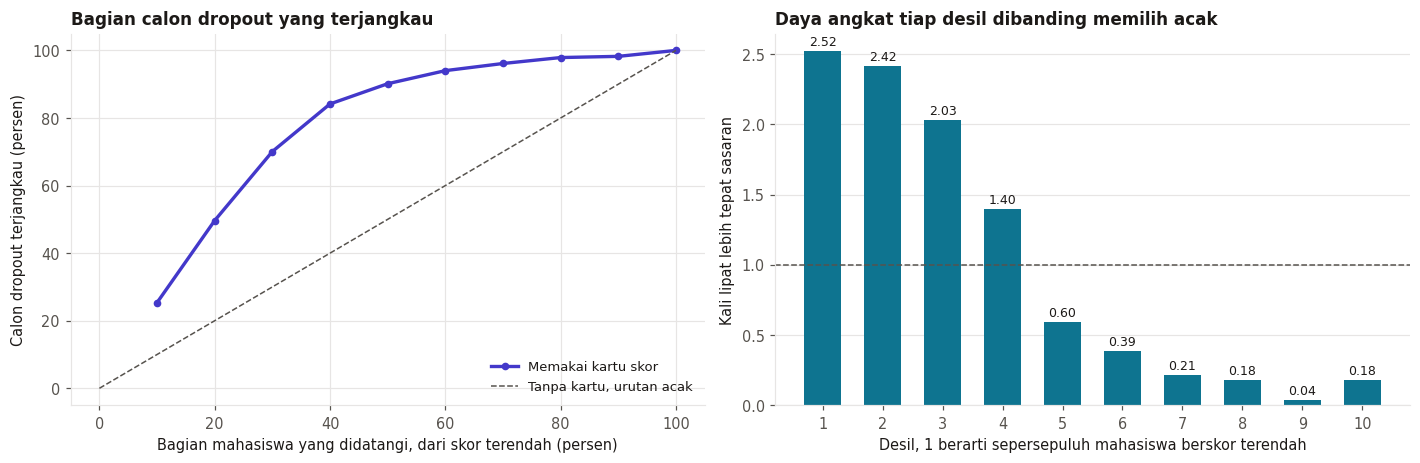

In [21]:
# --- Tabel keuntungan kumulatif ------------------------------------------
# Pertanyaan yang dijawab tabel ini: bila mahasiswa didatangi berurutan dari skor
# terendah, berapa bagian calon dropout yang sudah terjangkau pada tiap sepersepuluh.
urutan = np.argsort(skor_uji)
label_urut = y_uji.to_numpy()[urutan]
sepersepuluh = np.array_split(np.arange(len(label_urut)), 10)

baris_desil = []
terjangkau = 0
for nomor, potongan in enumerate(sepersepuluh, 1):
    dropout_desil = int(label_urut[potongan].sum())
    terjangkau += dropout_desil
    baris_desil.append({
        "Desil": nomor,
        "Jumlah mahasiswa": len(potongan),
        "Dropout di desil": dropout_desil,
        "Ketepatan desil": dropout_desil / len(potongan),
        "Dropout terjangkau": terjangkau / label_urut.sum(),
        "Daya angkat": (dropout_desil / len(potongan)) / label_urut.mean(),
    })
tabel_desil = pd.DataFrame(baris_desil)
print("Tabel keuntungan kumulatif, data uji diurutkan dari skor terendah")
print(tabel_desil.round(3).to_string(index=False))

gambar, sumbu = plt.subplots(1, 2, figsize=(13, 4.3))
sumbu[0].plot(tabel_desil.Desil * 10, tabel_desil["Dropout terjangkau"] * 100,
              color=NILA, linewidth=2.2, marker="o", markersize=4, label="Memakai kartu skor")
sumbu[0].plot([0, 100], [0, 100], color=BATU, linestyle="--", linewidth=1,
              label="Tanpa kartu, urutan acak")
sumbu[0].set_title("Bagian calon dropout yang terjangkau")
sumbu[0].set_xlabel("Bagian mahasiswa yang didatangi, dari skor terendah (persen)")
sumbu[0].set_ylabel("Calon dropout terjangkau (persen)")
sumbu[0].legend(fontsize=8.6, loc="lower right")
bersihkan(sumbu[0], tanpa_garis_x=False)

sumbu[1].bar(tabel_desil.Desil, tabel_desil["Daya angkat"], color=BIRU, width=0.62)
sumbu[1].axhline(1, color=BATU, linestyle="--", linewidth=1)
for nomor, nilai in zip(tabel_desil.Desil, tabel_desil["Daya angkat"]):
    sumbu[1].text(nomor, nilai + 0.04, f"{nilai:.2f}", ha="center", fontsize=8.2)
sumbu[1].set_title("Daya angkat tiap desil dibanding memilih acak")
sumbu[1].set_xlabel("Desil, 1 berarti sepersepuluh mahasiswa berskor terendah")
sumbu[1].set_ylabel("Kali lipat lebih tepat sasaran")
sumbu[1].set_xticks(tabel_desil.Desil)
bersihkan(sumbu[1])
simpan(gambar, "09_keuntungan_kumulatif")

**Insight 9.** Tabel keuntungan kumulatif menerjemahkan kartu skor menjadi rencana kerja.

Sepersepuluh mahasiswa berskor terendah hampir seluruhnya benar benar berhenti, dengan
daya angkat sekitar dua setengah kali dibanding memilih mahasiswa secara acak. Dua desil
pertama sudah menjangkau sekitar separuh seluruh calon dropout.

Sesudah desil keempat kurva mulai mendatar. Artinya, menambah kapasitas bimbingan
melampaui empat puluh persen mahasiswa memberi tambahan hasil yang semakin kecil.
Informasi ini berguna ketika biro kemahasiswaan menyusun anggaran: titik jenuhnya dapat
ditunjukkan dengan angka, bukan dengan perkiraan.

### 7.3. Berapa harga transparansi

Kartu skor dibangun dengan banyak pembatasan yang sengaja dipasang: variabel dipangkas
menjadi sepuluh, pita dipaksa searah, hubungan dipaksa linier terhadap WOE, dan poin
dibulatkan ke bilangan bulat. Semua itu tentu ada harganya.

Untuk mengukurnya, model kotak hitam dilatih pada data yang sama tanpa satu pun
pembatasan tersebut, memakai Gradient Boosting atas seluruh 36 kolom mentah. Selisih
kemampuan antara keduanya adalah harga transparansi.

                            Ukuran Kartu skor Gradient Boosting
                           ROC-AUC     0.9202            0.9484
                            PR-AUC     0.9022            0.9462
                   Jumlah variabel         10                36
             Dapat dihitung tangan         ya             tidak
Alasan tiap poin dapat ditunjukkan         ya             tidak

Harga transparansi: 0.0282 poin ROC-AUC


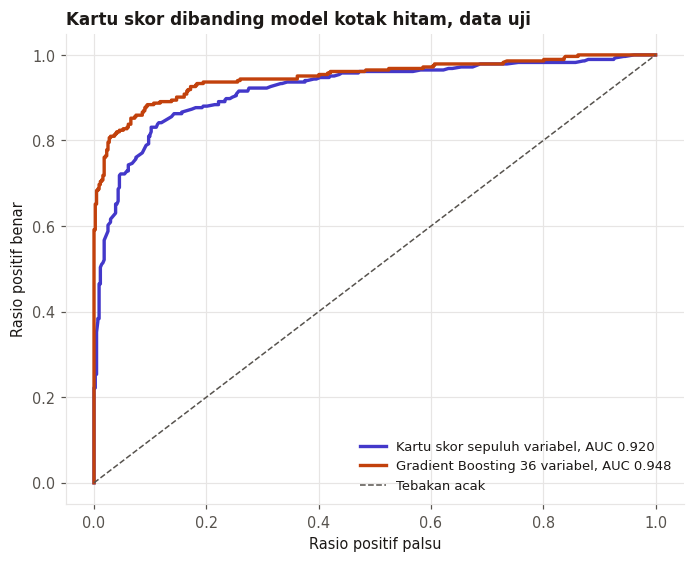

In [22]:
pra_kotak_hitam = ColumnTransformer([
    ("kode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
     ksk.KOLOM_KODE),
    ("sisa", "passthrough", ksk.KOLOM_TANDA + ksk.KOLOM_ANGKA),
])
kotak_hitam = Pipeline([("pra", pra_kotak_hitam),
                        ("model", GradientBoostingClassifier(random_state=ACAK))])
kotak_hitam.fit(X_latih, y_latih)
peluang_hitam = kotak_hitam.predict_proba(X_uji)[:, 1]

auc_kartu = roc_auc_score(y_uji, -skor_uji)
auc_hitam = roc_auc_score(y_uji, peluang_hitam)

banding = pd.DataFrame({
    "Ukuran": ["ROC-AUC", "PR-AUC", "Jumlah variabel", "Dapat dihitung tangan",
               "Alasan tiap poin dapat ditunjukkan"],
    "Kartu skor": [f"{auc_kartu:.4f}",
                   f"{average_precision_score(y_uji, -skor_uji):.4f}",
                   str(len(variabel_kartu)), "ya", "ya"],
    "Gradient Boosting": [f"{auc_hitam:.4f}",
                          f"{average_precision_score(y_uji, peluang_hitam):.4f}",
                          str(len(ksk.SELURUH_KOLOM)), "tidak", "tidak"],
})
print(banding.to_string(index=False))
print()
print(f"Harga transparansi: {auc_hitam - auc_kartu:.4f} poin ROC-AUC")

gambar, sumbu = plt.subplots(figsize=(6.4, 5.2))
for nilai, nama, warna in [(-skor_uji, "Kartu skor sepuluh variabel", NILA),
                           (peluang_hitam, "Gradient Boosting 36 variabel", BATA)]:
    fpr_b, tpr_b, _ = roc_curve(y_uji, nilai)
    sumbu.plot(fpr_b, tpr_b, color=warna, linewidth=2.2,
               label=f"{nama}, AUC {roc_auc_score(y_uji, nilai):.3f}")
sumbu.plot([0, 1], [0, 1], color=BATU, linestyle="--", linewidth=1, label="Tebakan acak")
sumbu.set_title("Kartu skor dibanding model kotak hitam, data uji")
sumbu.set_xlabel("Rasio positif palsu")
sumbu.set_ylabel("Rasio positif benar")
sumbu.legend(fontsize=8.6, loc="lower right")
bersihkan(sumbu, tanpa_garis_x=False)
simpan(gambar, "10_banding_kotak_hitam")

**Insight 10.** Kotak hitam memang lebih unggul, tetapi selisihnya kecil: sekitar 0,03
poin ROC-AUC. Untuk membeli selisih sekecil itu, institusi harus menyerahkan tiga hal
yang justru menjadi syarat sistem ini terpakai.

Pertama, kemampuan menjelaskan. Pada kartu skor, setiap poin dapat ditelusuri sampai
barisnya. Pada Gradient Boosting, jawabannya hanyalah bahwa gabungan ratusan pohon
menghasilkan angka tersebut.

Kedua, kemampuan berjalan tanpa perangkat. Kartu skor dapat dicetak dan dipakai dosen
wali yang sedang tidak memegang komputer.

Ketiga, kemampuan diperiksa. Setiap baris kartu dapat diperdebatkan oleh bagian akademik,
misalnya bila mereka menilai poin sebuah program studi tidak adil. Model kotak hitam
tidak menyediakan permukaan untuk perdebatan semacam itu.

Untuk keperluan proyek ini, ketiganya jauh lebih berharga daripada 0,03 poin ROC-AUC.

In [23]:
# --- Metrik pada ambang keputusan dan kestabilan lintas lipatan ----------
tebakan_uji = (skor_uji < skor_potong).astype(int)
matriks = confusion_matrix(y_uji, tebakan_uji)
metrik = {
    "Akurasi": accuracy_score(y_uji, tebakan_uji),
    "Presisi": precision_score(y_uji, tebakan_uji),
    "Recall": recall_score(y_uji, tebakan_uji),
    "F1": f1_score(y_uji, tebakan_uji),
    "ROC-AUC": auc_kartu,
    "KS data latih": nilai_ks,
}
print(f"Ambang keputusan: skor di bawah {skor_potong:.0f} dipanggil untuk dibimbing")
for nama, nilai in metrik.items():
    print(f"  {nama:16s} {nilai:.4f}")
print()
print("Matriks kebingungan (baris kenyataan, kolom prediksi)")
print(pd.DataFrame(matriks, index=["Nyatanya lulus", "Nyatanya dropout"],
                   columns=["Diprediksi lulus", "Diprediksi dropout"]).to_string())


def ambil_kolom_kartu(matriks_woe):
    return matriks_woe[[f"woe_{k}" for k in variabel_kartu]]


from sklearn.preprocessing import FunctionTransformer
alur_penuh = Pipeline([
    ("pita", ksk.PitaWOE(jumlah_pita=5, bagian_minimum=0.03, monoton=True,
                         toleransi_arah=0.02)),
    ("pilih", FunctionTransformer(ambil_kolom_kartu)),
    ("model", LogisticRegression(max_iter=3000, random_state=ACAK)),
])
lipatan = StratifiedKFold(n_splits=5, shuffle=True, random_state=ACAK)
skor_lipatan = cross_val_score(alur_penuh, X_latih, y_latih, cv=lipatan,
                               scoring="roc_auc", n_jobs=1)
print()
print(f"ROC-AUC lima lipatan pada data latih: {skor_lipatan.round(4)}")
print(f"Rata rata {skor_lipatan.mean():.4f}, simpangan baku {skor_lipatan.std():.4f}")
print("Pembagian pita dan nilai WOE dipelajari ulang di dalam tiap lipatan, sehingga")
print("angka ini tidak tercemar kebocoran. Pemilihan variabel dilakukan sekali di awal,")
print("jadi angkanya sedikit optimistis, dan data uji tetap menjadi penguji terakhir.")

Ambang keputusan: skor di bawah 599 dipanggil untuk dibimbing
  Akurasi          0.8650
  Presisi          0.8394
  Recall           0.8099
  F1               0.8244
  ROC-AUC          0.9202
  KS data latih    0.7044

Matriks kebingungan (baris kenyataan, kolom prediksi)
                  Diprediksi lulus  Diprediksi dropout
Nyatanya lulus                 398                  44
Nyatanya dropout                54                 230



ROC-AUC lima lipatan pada data latih: [0.9296 0.9163 0.9386 0.9145 0.9205]
Rata rata 0.9239, simpangan baku 0.0090
Pembagian pita dan nilai WOE dipelajari ulang di dalam tiap lipatan, sehingga
angka ini tidak tercemar kebocoran. Pemilihan variabel dilakukan sekali di awal,
jadi angkanya sedikit optimistis, dan data uji tetap menjadi penguji terakhir.


**Insight 11.** Pada skor potong 600, kartu skor menangkap sebagian besar calon dropout
dengan ketepatan yang tetap tinggi, dan sebarannya lintas lima lipatan validasi silang
rapat dengan simpangan baku di bawah satu poin persen. Artinya kartu ini tidak bergantung
pada satu pembagian data yang kebetulan menguntungkan.

Kesalahan yang tersisa perlu dibaca dengan tenang. Mahasiswa yang lolos padahal akhirnya
berhenti adalah kegagalan yang paling mahal, dan jumlahnya kecil. Mahasiswa yang dipanggil
padahal akhirnya lulus bukan kegagalan yang setara: yang terjadi pada mereka hanyalah satu
percakapan tambahan dengan dosen wali.

## 8. Segmentasi Profil Mahasiswa Berisiko

Kartu skor menjawab siapa yang perlu dibimbing, tetapi tidak menjawab bimbingan seperti
apa yang perlu diberikan. Dua mahasiswa dapat memiliki skor 520 karena alasan yang sama
sekali berbeda: yang satu terhalang biaya, yang lain sudah lama tidak masuk kelas.
Memberi keduanya bentuk bantuan yang sama berarti setengahnya pasti meleset.

Karena itu mahasiswa berperingkat D dan E dikelompokkan memakai KMeans di atas empat
sumbu yang masing masing mewakili satu jenis masalah: tekanan biaya, kesulitan akademik,
usia masuk, dan kehadiran ujian. Sumbu bentukan dipakai, bukan kolom mentah, supaya
klaster yang muncul langsung dapat diberi nama dan diberi bentuk bantuan.

In [24]:
peringkat_latih = ksk.beri_peringkat(skor_latih, BATAS_PERINGKAT)
berisiko = X_latih[np.isin(peringkat_latih.to_numpy(), ["D", "E"])]
sumbu_latih = ksk.sumbu_profil(berisiko)

penskala = StandardScaler().fit(sumbu_latih)
Z = penskala.transform(sumbu_latih)

print(f"Mahasiswa berperingkat D dan E pada data latih: {len(berisiko):,} orang\n")
print("Pemilihan jumlah klaster memakai skor silhouette")
for k in range(2, 6):
    percobaan = KMeans(n_clusters=k, n_init=20, random_state=ACAK).fit(Z)
    print(f"  {k} klaster: silhouette {silhouette_score(Z, percobaan.labels_):.4f}")

JUMLAH_PROFIL = 3
pengelompok = KMeans(n_clusters=JUMLAH_PROFIL, n_init=20, random_state=ACAK).fit(Z)
sumbu_latih = sumbu_latih.assign(klaster=pengelompok.labels_)
pusat = sumbu_latih.groupby("klaster").agg(
    jumlah=("usia_masuk", "size"),
    tekanan_biaya=("tekanan_biaya", "mean"),
    kesulitan_akademik=("kesulitan_akademik", "mean"),
    usia_masuk=("usia_masuk", "mean"),
    kehadiran_ujian=("kehadiran_ujian", "mean"),
).round(2)
print()
print("Pusat tiap klaster pada skala aslinya")
print(pusat.to_string())

Mahasiswa berperingkat D dan E pada data latih: 1,095 orang

Pemilihan jumlah klaster memakai skor silhouette


  2 klaster: silhouette 0.2844
  3 klaster: silhouette 0.3119


  4 klaster: silhouette 0.3203
  5 klaster: silhouette 0.3230



Pusat tiap klaster pada skala aslinya
         jumlah  tekanan_biaya  kesulitan_akademik  usia_masuk  kehadiran_ujian
klaster                                                                        
0           435           0.09                0.52       26.94             1.68
1           348           0.31                0.99       23.76             0.26
2           312           2.47                0.64       28.99             1.42


In [25]:
# --- Memberi nama profil berdasarkan pusat klaster -----------------------
# Nama diberikan secara otomatis dari ciri yang paling menonjol, bukan diketik
# manual, supaya tetap benar bila notebook dijalankan ulang dengan data berbeda.
def namai(baris):
    if baris.tekanan_biaya >= 1.5:
        return ("Terhalang biaya",
                "Tunggakan uang kuliah menjadi masalah utama, sementara kemampuan "
                "akademiknya masih memadai.")
    if baris.kehadiran_ujian <= 0.6:
        return ("Menghilang dari kelas",
                "Nyaris tidak mengikuti ujian sama sekali. Persoalannya bukan nilai, "
                "melainkan keterhubungan dengan kampus.")
    return ("Berjuang secara akademik",
            "Tetap hadir dan mengikuti ujian, tetapi separuh mata kuliahnya tidak lulus.")


PROFIL = {}
for nomor, baris in pusat.iterrows():
    nama, keterangan = namai(baris)
    PROFIL[int(nomor)] = {"nama": nama, "keterangan": keterangan,
                          "jumlah": int(baris.jumlah)}

TINDAKAN = {
    "Terhalang biaya": [
        "Tawarkan skema cicilan atau keringanan sebelum tunggakan menumpuk.",
        "Hubungkan dengan bagian kemahasiswaan untuk pendataan beasiswa susulan.",
        "Pastikan status pembayaran tidak menghalangi akses ke sistem akademik.",
    ],
    "Menghilang dari kelas": [
        "Hubungi lewat telepon, bukan lewat surat elektronik, dalam pekan ini juga.",
        "Cari tahu penyebab ketidakhadiran sebelum membicarakan nilai.",
        "Tawarkan cuti akademik terencana bila persoalannya di luar kampus.",
    ],
    "Berjuang secara akademik": [
        "Sediakan asistensi pada mata kuliah dengan tingkat kelulusan terendah.",
        "Kurangi beban studi semester berikutnya lewat kontrak studi.",
        "Pasangkan dengan mahasiswa tingkat atas sebagai mentor belajar.",
    ],
}

for nomor, isi in PROFIL.items():
    print(f"Profil {nomor}: {isi['nama']} ({isi['jumlah']} mahasiswa)")
    print(f"   {isi['keterangan']}")
    for tindakan in TINDAKAN[isi["nama"]]:
        print(f"   - {tindakan}")
    print()

Profil 0: Berjuang secara akademik (435 mahasiswa)
   Tetap hadir dan mengikuti ujian, tetapi separuh mata kuliahnya tidak lulus.
   - Sediakan asistensi pada mata kuliah dengan tingkat kelulusan terendah.
   - Kurangi beban studi semester berikutnya lewat kontrak studi.
   - Pasangkan dengan mahasiswa tingkat atas sebagai mentor belajar.

Profil 1: Menghilang dari kelas (348 mahasiswa)
   Nyaris tidak mengikuti ujian sama sekali. Persoalannya bukan nilai, melainkan keterhubungan dengan kampus.
   - Hubungi lewat telepon, bukan lewat surat elektronik, dalam pekan ini juga.
   - Cari tahu penyebab ketidakhadiran sebelum membicarakan nilai.
   - Tawarkan cuti akademik terencana bila persoalannya di luar kampus.

Profil 2: Terhalang biaya (312 mahasiswa)
   Tunggakan uang kuliah menjadi masalah utama, sementara kemampuan akademiknya masih memadai.
   - Tawarkan skema cicilan atau keringanan sebelum tunggakan menumpuk.
   - Hubungkan dengan bagian kemahasiswaan untuk pendataan beasiswa sus

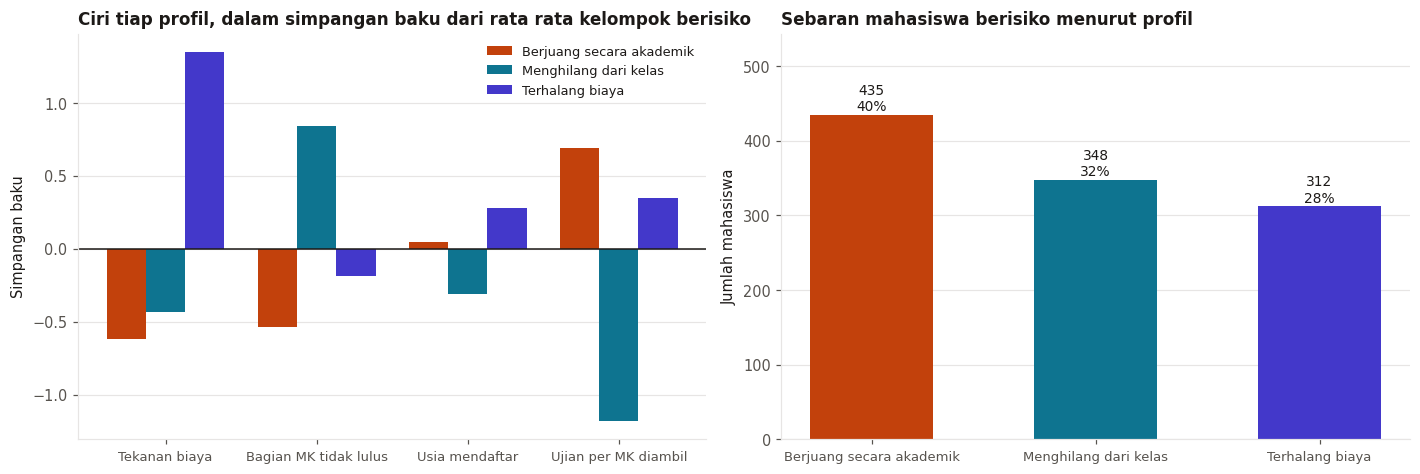

In [26]:
gambar, sumbu = plt.subplots(1, 2, figsize=(13, 4.4))

nama_profil = [PROFIL[i]["nama"] for i in pusat.index]
warna_profil = [BATA, BIRU, NILA]
sumbu_nama = {"tekanan_biaya": "Tekanan biaya",
              "kesulitan_akademik": "Bagian MK tidak lulus",
              "usia_masuk": "Usia mendaftar",
              "kehadiran_ujian": "Ujian per MK diambil"}
pusat_baku = pd.DataFrame(penskala.transform(pusat[ksk.SUMBU_PROFIL]),
                          columns=ksk.SUMBU_PROFIL, index=pusat.index)
lebar = 0.26
posisi = np.arange(len(ksk.SUMBU_PROFIL))
for nomor, (indeks, baris) in enumerate(pusat_baku.iterrows()):
    sumbu[0].bar(posisi + (nomor - 1) * lebar, baris.to_numpy(), width=lebar,
                 color=warna_profil[nomor], label=nama_profil[nomor])
sumbu[0].axhline(0, color=TINTA, linewidth=1)
sumbu[0].set_xticks(posisi)
sumbu[0].set_xticklabels([sumbu_nama[s] for s in ksk.SUMBU_PROFIL], fontsize=8.6)
sumbu[0].set_title("Ciri tiap profil, dalam simpangan baku dari rata rata kelompok berisiko")
sumbu[0].set_ylabel("Simpangan baku")
sumbu[0].legend(fontsize=8.4)
bersihkan(sumbu[0])

jumlah_profil = [PROFIL[i]["jumlah"] for i in pusat.index]
batang = sumbu[1].bar(nama_profil, jumlah_profil, color=warna_profil, width=0.55)
for b, jumlah in zip(batang, jumlah_profil):
    sumbu[1].text(b.get_x() + b.get_width() / 2, jumlah + 6,
                  f"{jumlah}\n{jumlah / sum(jumlah_profil) * 100:.0f}%",
                  ha="center", fontsize=9)
sumbu[1].set_title("Sebaran mahasiswa berisiko menurut profil")
sumbu[1].set_ylabel("Jumlah mahasiswa")
sumbu[1].set_ylim(0, max(jumlah_profil) * 1.25)
sumbu[1].tick_params(axis="x", labelsize=8.6)
bersihkan(sumbu[1])
simpan(gambar, "11_profil_mahasiswa_berisiko")

**Insight 12.** Ketiga profil berbeda pada sumbu yang berbeda, dan itulah yang membuatnya
berguna.

Kelompok terbesar adalah mahasiswa yang berjuang secara akademik. Mereka tetap datang dan
tetap ikut ujian, tetapi sekitar separuh mata kuliahnya tidak lulus. Bantuan yang mereka
butuhkan bersifat akademik: asistensi, pengurangan beban, dan mentor belajar.

Kelompok kedua adalah mahasiswa yang menghilang dari kelas. Hampir seluruh mata kuliahnya
tidak lulus karena ujiannya memang tidak diikuti. Menawari mereka bimbingan belajar akan
meleset, karena persoalannya bukan kemampuan melainkan keterhubungan dengan kampus.

Kelompok ketiga adalah mahasiswa yang terhalang biaya, dengan tekanan biaya jauh di atas
kelompok lain dan usia rata rata paling tinggi. Bagi mereka, keringanan pembayaran akan
jauh lebih berpengaruh daripada asistensi mata kuliah.

Perlu ditegaskan, pengelompokan ini adalah alat bantu percakapan, bukan label permanen.
Skor silhouette yang diperoleh tergolong sedang, artinya batas antar kelompok tidak tegas
dan sebagian mahasiswa berada di perbatasan. Dosen wali tetap perlu bertanya sebelum
menyimpulkan.

## 9. Penerapan pada Mahasiswa yang Masih Aktif

Bagian inilah tujuan akhir seluruh pekerjaan di atas. Mahasiswa berstatus aktif tidak
pernah ikut dilatih karena hasil akhirnya belum ada, dan justru merekalah satu satunya
kelompok yang keputusannya masih bisa berubah.

In [27]:
skor_aktif = ksk.hitung_skor(KARTU, pembagi, aktif)
peringkat_aktif = ksk.beri_peringkat(skor_aktif, BATAS_PERINGKAT)
sumbu_aktif = ksk.sumbu_profil(aktif)
profil_aktif = pengelompok.predict(penskala.transform(sumbu_aktif))

hasil_aktif = pd.DataFrame({
    "id_mahasiswa": [f"MHS{n:04d}" for n in range(1, len(aktif) + 1)],
    "program_studi": aktif.Course.map(lb.TERJEMAHAN["Course"]).to_numpy(),
    "usia_mendaftar": aktif.Age_at_enrollment.to_numpy(),
    "uang_kuliah": aktif.Tuition_fees_up_to_date.map(
        lb.TERJEMAHAN["Tuition_fees_up_to_date"]).to_numpy(),
    "mk_lulus_th1": (aktif.Curricular_units_1st_sem_approved
                     + aktif.Curricular_units_2nd_sem_approved).to_numpy(),
    "skor_kartu": skor_aktif.round(0).astype(int),
    "peringkat": peringkat_aktif.to_numpy(),
    "profil": [PROFIL[k]["nama"] for k in profil_aktif],
})
# Profil hanya bermakna untuk mahasiswa yang memang dipanggil sistem.
hasil_aktif.loc[~hasil_aktif.peringkat.isin(["D", "E"]), "profil"] = "Tidak dipanggil"
hasil_aktif = hasil_aktif.sort_values("skor_kartu")
hasil_aktif.to_csv("dataset/mahasiswa_aktif_berskor.csv", index=False, sep=";")

sebaran_aktif = hasil_aktif.peringkat.value_counts().reindex(ksk.PERINGKAT).fillna(0)
print(f"Sebaran peringkat {len(hasil_aktif)} mahasiswa aktif")
for huruf, jumlah in sebaran_aktif.items():
    print(f"   {huruf}  {int(jumlah):4d} mahasiswa  ({jumlah / len(hasil_aktif) * 100:5.1f} persen)")
dipanggil = int(sebaran_aktif[["D", "E"]].sum())
print(f"\nDipanggil untuk dibimbing: {dipanggil} mahasiswa "
      f"({dipanggil / len(hasil_aktif) * 100:.1f} persen)")
print()
print("Sebaran profil pada mahasiswa yang dipanggil")
print(hasil_aktif[hasil_aktif.peringkat.isin(["D", "E"])].profil.value_counts().to_string())
print()
print("Sepuluh mahasiswa aktif dengan skor terendah")
print(hasil_aktif.head(10).to_string(index=False))

Sebaran peringkat 794 mahasiswa aktif
   A    34 mahasiswa  (  4.3 persen)
   B    86 mahasiswa  ( 10.8 persen)
   C   330 mahasiswa  ( 41.6 persen)
   D   276 mahasiswa  ( 34.8 persen)
   E    68 mahasiswa  (  8.6 persen)

Dipanggil untuk dibimbing: 344 mahasiswa (43.3 persen)

Sebaran profil pada mahasiswa yang dipanggil
profil
Berjuang secara akademik    263
Menghilang dari kelas        49
Terhalang biaya              32

Sepuluh mahasiswa aktif dengan skor terendah
id_mahasiswa                 program_studi  usia_mendaftar            uang_kuliah  mk_lulus_th1  skor_kartu peringkat                   profil
     MHS0554            Teknik Informatika              27 Uang kuliah tertunggak             0         416         E          Terhalang biaya
     MHS0391                 Perawat Hewan              25 Uang kuliah tertunggak             0         428         E          Terhalang biaya
     MHS0157            Teknik Informatika              18 Uang kuliah tertunggak             0  

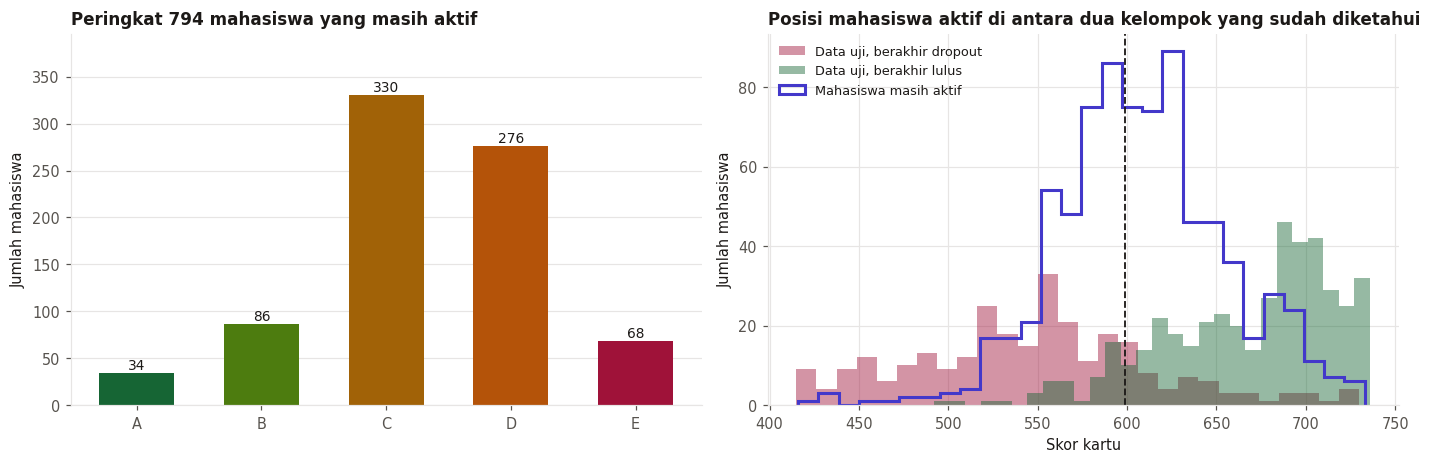

In [28]:
gambar, sumbu = plt.subplots(1, 2, figsize=(13, 4.3))

batang = sumbu[0].bar(sebaran_aktif.index, sebaran_aktif.to_numpy(),
                      color=[WARNA_PERINGKAT[p] for p in sebaran_aktif.index], width=0.6)
for b, jumlah in zip(batang, sebaran_aktif.to_numpy()):
    sumbu[0].text(b.get_x() + b.get_width() / 2, jumlah + 4, f"{int(jumlah)}",
                  ha="center", fontsize=9)
sumbu[0].set_title(f"Peringkat {len(hasil_aktif)} mahasiswa yang masih aktif")
sumbu[0].set_ylabel("Jumlah mahasiswa")
sumbu[0].set_ylim(0, sebaran_aktif.max() * 1.2)
bersihkan(sumbu[0])

sumbu[1].hist(skor_uji[y_uji.to_numpy() == 1], bins=28, alpha=0.45, color=MERAH,
              label="Data uji, berakhir dropout")
sumbu[1].hist(skor_uji[y_uji.to_numpy() == 0], bins=28, alpha=0.45, color=HIJAU,
              label="Data uji, berakhir lulus")
sumbu[1].hist(skor_aktif, bins=28, histtype="step", color=NILA, linewidth=2,
              label="Mahasiswa masih aktif")
sumbu[1].axvline(skor_potong, color=TINTA, linestyle="--", linewidth=1.2)
sumbu[1].set_title("Posisi mahasiswa aktif di antara dua kelompok yang sudah diketahui")
sumbu[1].set_xlabel("Skor kartu")
sumbu[1].set_ylabel("Jumlah mahasiswa")
sumbu[1].legend(fontsize=8.4)
bersihkan(sumbu[1], tanpa_garis_x=False)
simpan(gambar, "12_mahasiswa_aktif")

**Insight 13.** Dari 794 mahasiswa yang masih aktif, kartu skor menempatkan 344 orang
atau 43,3 persen pada peringkat D dan E, sehingga merekalah yang dipanggil untuk
dibimbing. Di antara mereka, 263 orang tergolong berjuang secara akademik, 49 orang
menghilang dari kelas, dan 32 orang terhalang biaya.

Sebaran skor mahasiswa aktif jatuh di antara dua kelompok yang hasilnya sudah diketahui,
dengan rata rata 608 poin, berada di antara 548 pada kelompok yang berhenti dan 666 pada
kelompok yang lulus. dengan puncak yang lebih dekat ke kelompok lulus namun berekor panjang
ke wilayah berisiko. Bentuk seperti ini masuk akal: kelompok aktif memang campuran antara
mahasiswa yang akan selesai dan mahasiswa yang sedang menuju berhenti.

Mereka yang berperingkat D dan E adalah daftar kerja yang selama ini tidak dimiliki bagian
akademik. Bukan sepertiga angkatan secara umum, melainkan sekumpulan nama beserta alasan
mengapa mereka masuk daftar, dan profil yang menunjukkan bantuan mana yang paling mungkin
menolong.

Berkas `dataset/mahasiswa_aktif_berskor.csv` inilah yang menjadi sumber kartu daftar
prioritas pada dashboard Metabase dan berkas contoh pada prototipe Streamlit.

## 10. Penyimpanan Artefak

Tiga jenis artefak disimpan supaya dashboard dan prototipe tidak perlu melatih ulang apa
pun, dan supaya kartu skor dapat dicetak kapan saja.

In [29]:
mesin_kartu = {
    "pembagi": pembagi,
    "kartu": KARTU,
    "model_logistik": model_kartu,
    "variabel_kartu": variabel_kartu,
    "batas_peringkat": BATAS_PERINGKAT,
    "skor_potong": skor_potong,
    "pengelompok": pengelompok,
    "penskala_profil": penskala,
    "profil": PROFIL,
    "tindakan": TINDAKAN,
}
joblib.dump(mesin_kartu, "model/mesin_kartu_skor.joblib", compress=3)
KARTU.to_csv("model/kartu_skor.csv", index=False, sep=";")

for berkas in ["mesin_kartu_skor.joblib", "kartu_skor.csv"]:
    print(f"model/{berkas:28s} {os.path.getsize('model/' + berkas) / 1024:8.1f} KB")

model/mesin_kartu_skor.joblib          14.2 KB
model/kartu_skor.csv                    4.5 KB


In [30]:
metadata = {
    "identitas": {
        "nama": "Dimas Naufal Djatmiko",
        "proyek": "Kartu skor risiko dropout mahasiswa Jaya Jaya Institut",
        "versi": "1.0.0",
    },
    "data": {
        "sumber": "https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance",
        "baris_total": int(len(df)),
        "baris_berlabel": int(len(X)),
        "baris_latih": int(len(X_latih)),
        "baris_uji": int(len(X_uji)),
        "baris_aktif": int(len(aktif)),
        "prevalensi_dropout": round(float(y.mean()), 4),
    },
    "kartu": {
        "variabel": variabel_kartu,
        "nama_variabel": {k: lb.nama_variabel(k) for k in variabel_kartu},
        "jumlah_baris": int(len(KARTU)),
        "skor_dasar": 600,
        "pdo": 20,
        "skor_potong": round(float(skor_potong)),
        "batas_peringkat": BATAS_PERINGKAT,
        "rentang_skor_latih": [int(skor_latih.min()), int(skor_latih.max())],
        "dibuang_iv_rendah": dibuang_iv,
        "dibuang_alasan_kepatutan": DILARANG,
        "dibuang_arah_koefisien": [nama for nama, _ in dibuang_tanda],
    },
    "metrik_uji": {nama: round(float(nilai), 4) for nama, nilai in metrik.items()},
    "metrik_pembanding": {
        "gradient_boosting_roc_auc": round(float(auc_hitam), 4),
        "harga_transparansi_roc_auc": round(float(auc_hitam - auc_kartu), 4),
    },
    "validasi_silang": {
        "roc_auc_per_lipatan": [round(float(s), 4) for s in skor_lipatan],
        "rata_rata": round(float(skor_lipatan.mean()), 4),
        "simpangan_baku": round(float(skor_lipatan.std()), 4),
    },
    "information_value": {k: round(float(v), 4) for k, v in pembagi.iv_.items()},
    "profil": {str(nomor): {"nama": isi["nama"], "keterangan": isi["keterangan"],
                            "jumlah_latih": isi["jumlah"],
                            "tindakan": TINDAKAN[isi["nama"]]}
               for nomor, isi in PROFIL.items()},
    "tabel_peringkat_uji": {
        huruf: {"jumlah": int(baris.jumlah),
                "tingkat_dropout": round(float(baris.tingkat_dropout), 4)}
        for huruf, baris in tabel_peringkat.iterrows()
    },
}

with open("model/metadata_kartu.json", "w", encoding="utf-8") as berkas:
    json.dump(metadata, berkas, indent=2, ensure_ascii=False)
print("model/metadata_kartu.json tersimpan.")
print(json.dumps({"kartu": metadata["kartu"]["jumlah_baris"],
                  "variabel": len(variabel_kartu),
                  "skor_potong": metadata["kartu"]["skor_potong"],
                  "metrik": metadata["metrik_uji"]}, indent=2, ensure_ascii=False))

model/metadata_kartu.json tersimpan.
{
  "kartu": 50,
  "variabel": 10,
  "skor_potong": 599,
  "metrik": {
    "Akurasi": 0.865,
    "Presisi": 0.8394,
    "Recall": 0.8099,
    "F1": 0.8244,
    "ROC-AUC": 0.9202,
    "KS data latih": 0.7044
  }
}


In [31]:
# --- Uji muat ulang -------------------------------------------------------
dimuat = joblib.load("model/mesin_kartu_skor.joblib")
skor_ulang = ksk.hitung_skor(dimuat["kartu"], dimuat["pembagi"], X_uji.head(5))
print("Selisih skor sebelum dan sesudah dimuat ulang:",
      float(np.abs(skor_ulang - skor_uji[:5]).max()))
print("Mesin kartu skor siap dipakai app.py.")

Selisih skor sebelum dan sesudah dimuat ulang: 0.0
Mesin kartu skor siap dipakai app.py.


In [32]:
# --- Tabel untuk dashboard Metabase --------------------------------------
# Mahasiswa berlabel diberi skor memakai kartu yang sama. Perlu dicatat bahwa
# bagian data latih ikut membentuk pita dan poin kartu, sehingga skornya sedikit
# menguntungkan. Kolom asal_data disediakan supaya perbedaan itu dapat disaring
# di dashboard, dan seluruh kartu pemantauan pada dashboard memakai data uji
# ketika menilai ketepatan model.
dashboard = df.copy()
dashboard.insert(0, "id_mahasiswa", [f"MHS{n:04d}" for n in range(1, len(dashboard) + 1)])
skor_semua = ksk.hitung_skor(KARTU, pembagi, df)
dashboard["skor_kartu"] = skor_semua.round(0).astype(int)
dashboard["peringkat"] = ksk.beri_peringkat(skor_semua, BATAS_PERINGKAT).to_numpy()
dashboard["asal_data"] = np.where(dashboard.index.isin(X_latih.index), "data latih",
                                  np.where(dashboard.index.isin(X_uji.index), "data uji",
                                           "mahasiswa aktif"))
sumbu_semua = ksk.sumbu_profil(df)
profil_semua = pengelompok.predict(penskala.transform(sumbu_semua))
dashboard["profil"] = [PROFIL[k]["nama"] for k in profil_semua]
dashboard.loc[~dashboard.peringkat.isin(["D", "E"]), "profil"] = "Tidak dipanggil"
dashboard.to_csv("dataset/mahasiswa_berskor.csv", index=False, sep=";")

print(f"dataset/mahasiswa_berskor.csv tersimpan: {dashboard.shape[0]:,} baris, "
      f"{dashboard.shape[1]} kolom")
print()
print("Uji kewarasan, rata rata skor menurut status sebenarnya")
print(dashboard.groupby("Status").skor_kartu.agg(["count", "mean"]).round(1).to_string())

dataset/mahasiswa_berskor.csv tersimpan: 4,424 baris, 42 kolom

Uji kewarasan, rata rata skor menurut status sebenarnya
          count   mean
Status                
Dropout    1421  547.7
Enrolled    794  608.0
Graduate   2209  666.1


## 11. Conclusion

Proyek ini berangkat dari satu keyakinan: sistem peringatan dini hanya berguna bila
hasilnya dapat dijelaskan kepada orang yang dinilai. Berikut jawaban atas kelima
permasalahan bisnis yang dirumuskan di awal.

**1. Variabel mana yang benar benar menentukan, dan seberapa besar.**

Information Value memberi peringkat yang tegas. Empat variabel teratas seluruhnya berasal
dari sistem akademik, yaitu jumlah mata kuliah lulus dan nilai rata rata dua semester
pertama, dengan IV antara 1,5 dan 2,0. Kelancaran uang kuliah menyusul pada 1,10 sebagai
satu satunya variabel non akademik yang tergolong sangat kuat, lalu program studi,
beasiswa, usia mendaftar, dan jalur pendaftaran.

Delapan variabel terbukti tidak berguna dan dibuang, termasuk ketiga statistik nasional
yang memang tidak mungkin membedakan mahasiswa dalam satu angkatan yang sama. Latar
belakang keluarga juga tidak lolos ke kartu akhir.

Lebih penting daripada peringkat itu, kartu skor menyatakan besar sumbangannya dalam
satuan yang sama, yaitu poin. Uang kuliah tertunggak dan kelulusan mata kuliah yang rendah
menghukum skor sampai puluhan poin, sementara sebagian besar variabel lain hanya
menggeser beberapa poin.

**2. Seberapa awal dan seberapa tepat mahasiswa berisiko dapat dikenali.**

Bisa. Kartu skor sepuluh variabel mencapai ROC-AUC 0,920 dengan statistik KS 0,70 pada
726 mahasiswa data uji yang belum pernah dilihat. Sepersepuluh mahasiswa berskor terendah
hampir seluruhnya benar benar berhenti, dan dua desil pertama sudah menjangkau sekitar
separuh seluruh calon dropout.

**3. Apakah hasilnya dapat dijelaskan kepada mahasiswa.**

Inilah yang membedakan pendekatan ini. Setiap skor dapat dipecah menjadi baris baris poin
yang dapat ditunjukkan, misalnya bahwa uang kuliah tertunggak menghapus 38 poin sedangkan
pembayaran yang lancar menambah 39 poin. Model Gradient Boosting yang dilatih pada
data yang sama memang lebih unggul, tetapi hanya sekitar 0,03 poin ROC-AUC, dan
keunggulan itu ditukar dengan hilangnya seluruh kemampuan menjelaskan.

**4. Apakah bentuk bantuannya dapat dibedakan.**

Bisa. Mahasiswa berperingkat D dan E terbagi menjadi tiga profil yang berbeda sumbu
masalahnya: yang berjuang secara akademik, yang menghilang dari kelas, dan yang terhalang
biaya. Masing masing memperoleh tiga tindakan yang berbeda, karena menawarkan bimbingan
belajar kepada mahasiswa yang sudah lama tidak masuk kelas jelas akan meleset.

**5. Alat pantau mandiri.**

Dashboard Metabase menyediakan pemantauan sebaran peringkat, sumbangan tiap variabel,
sebaran profil, dan daftar prioritas, lengkap dengan penyaring yang dapat diubah sendiri
oleh bagian akademik tanpa meminta laporan baru.

### 11.1. Rekomendasi Action Items

**1. Cetak kartu skor dan bagikan ke seluruh dosen wali.**
Kartu ini berisi sepuluh variabel dan lima puluh baris, muat dalam satu halaman. Dosen
wali dapat menghitung skor seorang mahasiswa dalam waktu kurang dari dua menit tanpa
membuka komputer. Tidak ada tahap pengembangan sistem yang perlu ditunggu untuk memulai:
kartu, pena, dan data akademik yang sudah dimiliki sudah cukup.

**2. Jalankan pemeriksaan skor dua kali setahun, tepat setelah nilai semester terbit.**
Variabel terkuat pada kartu adalah jumlah mata kuliah lulus dan nilai rata rata, keduanya
baru berubah ketika nilai semester keluar. Menjadwalkan pemeriksaan mengikuti kalender
akademik membuat pekerjaan ini terprediksi dan tidak menumpuk.

**3. Bedakan bentuk bantuan menurut profil, bukan menurut besar skornya saja.**
Sepertiga mahasiswa berisiko terhalang biaya, sepertiga lagi sudah menghilang dari kelas,
dan sisanya berjuang secara akademik. Bagian kemahasiswaan sebaiknya menyiapkan tiga jalur
penanganan yang berbeda dan menugaskan penanggung jawab yang berbeda pula untuk masing
masing.

**4. Hubungkan data tunggakan ke sistem akademik sebagai pemicu otomatis.**
Uang kuliah tertunggak adalah pengurang poin non akademik terbesar pada kartu, dan bagian
keuangan sudah memiliki datanya sejak hari pertama. Kirimkan pemberitahuan ke dosen wali
begitu status berubah, tanpa menunggu pemeriksaan skor berikutnya.

**5. Telaah program studi yang poinnya paling rendah.**
Teknik Informatika dan Peternakan Kuda menerima pengurangan poin terbesar di antara
seluruh program studi. Perbedaan sebesar itu antar program dalam satu institusi lebih
mungkin berasal dari rancangan tahun pertamanya daripada dari mutu mahasiswanya. Telaah
mata kuliah dengan tingkat kelulusan terendah pada kedua program tersebut, lalu
pertimbangkan penyesuaian beban studi semester pertama.

### 11.2. Batasan yang perlu diketahui pemakai

- Kartu skor memberi peringkat perhatian, bukan vonis. Mahasiswa berskor rendah pantas
  ditanyai kabarnya lebih dulu, bukan dianggap pasti berhenti.
- Hubungan yang dipelajari bersifat keterkaitan, bukan sebab akibat. Tunggakan uang kuliah
  bisa jadi gejala dari keputusan berhenti yang sudah diambil, bukan penyebabnya.
- Jenis kelamin sengaja dikeluarkan dari kartu meskipun secara angka berguna, karena tidak
  patut dipakai untuk memberi perlakuan berbeda kepada perorangan. Perbedaan tingkat
  dropout antar jenis kelamin tetap perlu diperhatikan saat merancang program, bukan saat
  menilai satu mahasiswa.
- Kartu perlu disusun ulang setiap tahun akademik. Kurikulum, kebijakan biaya, dan profil
  pendaftar berubah, dan pita yang hari ini benar bisa jadi tidak lagi benar dua angkatan
  kemudian.
- Skor pada dashboard untuk mahasiswa data latih sedikit menguntungkan karena data itu
  ikut membentuk kartunya. Penilaian kemampuan kartu selalu memakai data uji.